#  IndabaX Nigeria 2026 — Emission Forecasting Competition (1st Place Solution)


by

 Precious Odutola

---

## 🗺️ Notebook Structure

| Section | .
|---|---|
| 1. Understanding the Problem |
| 2. Exploratory Data Analysis |
| 3. Feature Engineering | |
| 4. Model Training |
| 5. Mirror Month Calibration |
| 6. Final Blend & Output |
| 7. Note on Reproducibility |

---
# Section 1 — Understanding the Problem

## What are we predicting?

We are predicting **emission levels** at different locations around the world,  at different times of day, on different days of the year.

Each row in the dataset represents one measurement at one location at one moment in time.  
The features tell us **where** (Latitude, Longitude) and **when** (Hour, Month, DayOfYear etc).  
The target is **Emmission** — a continuous number representing the pollution level.

## The Hidden Trap

At first glance this looks like a standard regression problem. But there are two structural challenges hiding in the data that determine everything:

**Challenge 1 — Time gap between train and test**

> Training data: **January → September**
> Test data: **October → December**

The model is being asked to predict months it has *never seen before*.  
Like studying chapters 1–9 of a textbook and being tested on chapters 10–12.

**Challenge 2 — Almost every test location is brand new**

About 99% of locations in the test set never appeared in training.  
So the model cannot rely on remembering a specific location's emission level.  
It must learn *general patterns* i.e time of day, day of week, season and apply them to places it has never visited.

These two challenges together mean this is fundamentally a **temporal extrapolation problem**, not a spatial memorisation problem.

Spatial memorisation → “Have I seen something like this before?”

Temporal extrapolation → “Based on past trends, what will happen next?”

---
# Section 2 — Exploratory Data Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import KFold
import warnings
warnings.filterwarnings("ignore")

train  = pd.read_csv("train.csv")
test   = pd.read_csv("test.csv")
sample = pd.read_csv("sampleubmission.csv")

print("TRAIN:")
print(f"Rows:    {len(train):,}")
print(f"Columns: {list(train.columns)}")
print(f"Months:  {sorted(train.Month.unique())}")
print(f"\nEmission stats:")
print(train["Emmission"].describe().round(2))

print("\nTEST:")
print(f"Rows:    {len(test):,}")
print(f"Months:  {sorted(test.Month.unique())}")


print("\nMISSING VALUES:")
print(f"Train: {train.isnull().sum().sum()} missing values")
print(f"Test:  {test.isnull().sum().sum()} missing values")

TRAIN:
Rows:    5,636
Columns: ['ID', 'Latitude', 'Longitude', 'DayOfYear', 'DayOfWeek', 'Hour', 'Month', 'Emmission']
Months:  [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Emission stats:
count    5636.00
mean       20.63
std        38.88
min         3.50
25%         8.89
50%        14.05
75%        22.50
max      1001.21
Name: Emmission, dtype: float64

TEST:
Rows:    2,000
Months:  [np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

MISSING VALUES:
Train: 0 missing values
Test:  0 missing values


### Key observation 1: the target is heavily skewed

Most emission values are small (around 14), but a few extreme outliers go all the way up to 1001. This kind of distribution causes problems for ML models as they get distracted trying to fit the extreme values and perform poorly on the majority.

**The fix**: train on `log1p(Emmission)` instead of raw values, then convert back at the end with `expm1()`. This compresses the extreme values and makes the distribution much more manageable.

In [ ]:
print("Emission distribution:")
print(f"  Mean:     {train['Emmission'].mean():.2f}")
print(f"  Median:   {train['Emmission'].median():.2f}")
print(f"  Max:      {train['Emmission'].max():.2f}")
print(f"  Skewness: {train['Emmission'].skew():.2f}  ← very skewed")
print()
print("After log1p transform:")
print(f"  Skewness: {np.log1p(train['Emmission']).skew():.2f}  ← much better")

Emission distribution:
  Mean:     20.63
  Median:   14.05
  Max:      1001.21
  Skewness: 16.29  ← very skewed

After log1p transform:
  Skewness: 0.93  ← much better


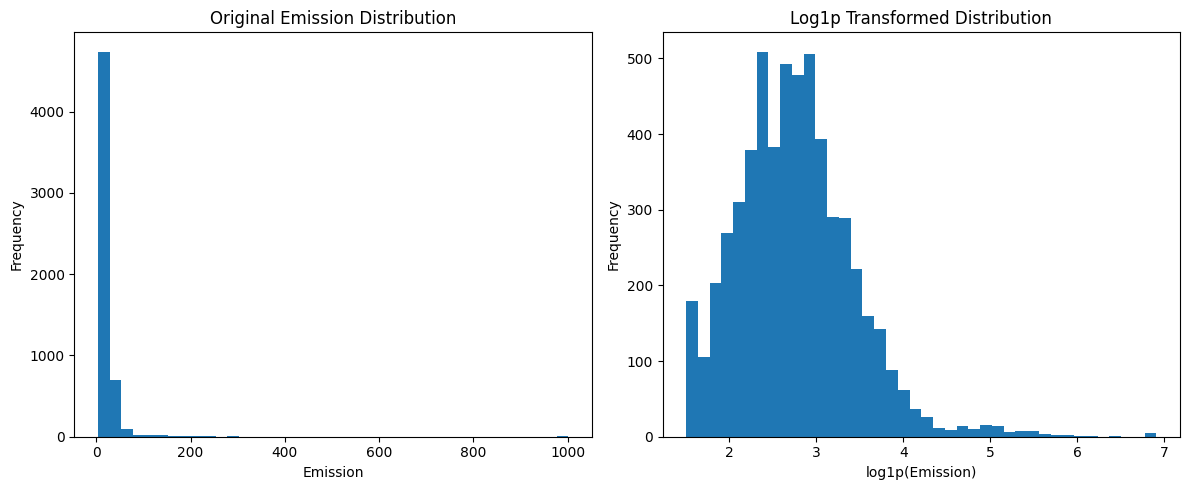

Original skewness: 16.29
Log1p skewness: 0.93


In [ ]:
# Original emission values
original = train["Emmission"]

# Log-transformed values
log_transformed = np.log1p(original)

# Create figure
plt.figure(figsize=(12, 5))

# Original distribution
plt.subplot(1, 2, 1)
plt.hist(original, bins=40)
plt.title("Original Emission Distribution")
plt.xlabel("Emission")
plt.ylabel("Frequency")

# Log-transformed distribution
plt.subplot(1, 2, 2)
plt.hist(log_transformed, bins=40)
plt.title("Log1p Transformed Distribution")
plt.xlabel("log1p(Emission)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Print statistics
print("Original skewness:", round(original.skew(), 2))
print("Log1p skewness:", round(log_transformed.skew(), 2))

### Key observation 2: test is dominated by East Asia and South Asia

In [ ]:
def tag_regions(df):
    df = df.copy()
    df["region"] = "OTHER"
    df.loc[(df.Longitude > 100) & (df.Latitude > 10) & (df.Latitude < 55),  "region"] = "EA"  # East Asia
    df.loc[(df.Longitude > 60)  & (df.Longitude < 100) &
           (df.Latitude > 5)   & (df.Latitude < 35),                         "region"] = "SA"  # South Asia
    df.loc[(df.Longitude > -10) & (df.Longitude < 45) & (df.Latitude > 35),  "region"] = "EU"  # Europe
    df.loc[(df.Longitude < -60) & (df.Latitude > 20),                         "region"] = "NA"  # North America
    df.loc[df.Latitude < -15,                                                  "region"] = "SH"  # Southern Hemisphere
    return df

train = tag_regions(train)
test  = tag_regions(test)

print("Train region distribution:")
for r, n in train["region"].value_counts().items():
    print(f"  {r}: {n:,} rows ({n/len(train)*100:.1f}%)")

print("\nTest region distribution:")
for r, n in test["region"].value_counts().items():
    print(f"  {r}: {n:,} rows ({n/len(test)*100:.1f}%)")

print("\n⚠️  East Asia makes up 49.5% of the test set")

Train region distribution:
  EA: 2,247 rows (39.9%)
  NA: 1,867 rows (33.1%)
  EU: 808 rows (14.3%)
  SH: 340 rows (6.0%)
  OTHER: 199 rows (3.5%)
  SA: 175 rows (3.1%)

Test region distribution:
  EA: 998 rows (49.9%)
  SA: 335 rows (16.8%)
  NA: 277 rows (13.9%)
  EU: 229 rows (11.5%)
  SH: 91 rows (4.5%)
  OTHER: 70 rows (3.5%)

⚠️  East Asia makes up 49.5% of the test set


###  Key observation 3: East Asia and South Asia have extreme winter seasonality

This is the most important finding in the entire EDA.  
East Asia emissions in January are nearly **9× higher** than in September.  
The model trained only on January–September will see September (the annual low) and assume October–December continue at that low level. but they don't.

In [ ]:
ea = train[train["region"] == "EA"]
sa = train[train["region"] == "SA"]

print("East Asia — average emission by month:")
print("-" * 35)
for month, mean in ea.groupby("Month")["Emmission"].mean().items():
    bar = "█" * int(mean / 5)
    print(f"  Month {month:2d}: {mean:6.1f}  {bar}")

print("\nSouth Asia — average emission by month:")
print("-" * 35)
for month, mean in sa.groupby("Month")["Emmission"].mean().items():
    bar = "█" * int(mean / 10)
    print(f"  Month {month:2d}: {mean:6.1f}  {bar}")

print("\n⚠️  Oct, Nov, Dec are MISSING from training but they should be HIGH (winter peak)")

East Asia — average emission by month:
-----------------------------------
  Month  1:   71.9  ██████████████
  Month  2:   43.0  ████████
  Month  3:   67.5  █████████████
  Month  4:   30.2  ██████
  Month  5:   15.8  ███
  Month  6:   17.6  ███
  Month  7:   17.3  ███
  Month  8:   23.9  ████
  Month  9:    8.4  █

South Asia — average emission by month:
-----------------------------------
  Month  1:   94.1  █████████
  Month  2:  163.7  ████████████████
  Month  3:   44.5  ████
  Month  4:   20.5  ██
  Month  5:  119.3  ███████████
  Month  6:   17.3  █
  Month  7:   33.8  ███
  Month  8:   16.1  █
  Month  9:   23.4  ██

⚠️  Oct, Nov, Dec are MISSING from training but they should be HIGH (winter peak)


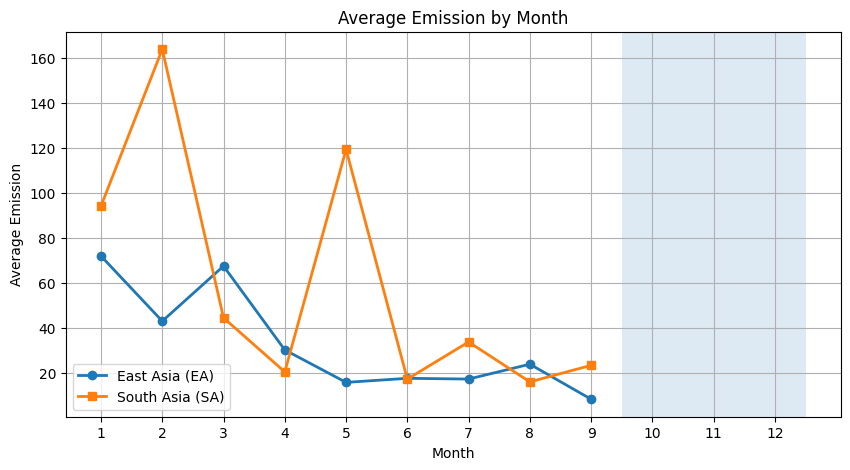

In [ ]:
# Separate regions
ea = train[train["region"] == "EA"]
sa = train[train["region"] == "SA"]

# Monthly averages
ea_monthly = ea.groupby("Month")["Emmission"].mean()
sa_monthly = sa.groupby("Month")["Emmission"].mean()

# Create figure
plt.figure(figsize=(10, 5))

# Plot East Asia
plt.plot(
    ea_monthly.index,
    ea_monthly.values,
    marker='o',
    linewidth=2,
    label='East Asia (EA)'
)

# Plot South Asia
plt.plot(
    sa_monthly.index,
    sa_monthly.values,
    marker='s',
    linewidth=2,
    label='South Asia (SA)'
)

# Highlight missing months
for month in [10, 11, 12]:
    plt.axvspan(month - 0.5, month + 0.5, alpha=0.15)

# Labels
plt.title("Average Emission by Month")
plt.xlabel("Month")
plt.ylabel("Average Emission")
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True)

plt.show()

---
# Section 3 — Feature Engineering


The raw columns (Hour, Month, DayOfWeek) are just numbers — 1, 2, 3...  
But the model doesn't automatically know that **December (12) and January (1) are neighbours**,  or that **Hour 23 and Hour 0 are only one hour apart**.

We need to teach the model that time is circular, not linear.

## Cyclical Encoding : Teaching the Model About Circles

We convert each time feature into **two values: a sine and a cosine**.    
North (0°) and North-again (360°) are the same place, just like  
December and January are the same season.

```
Raw month 12 → month_sin = 0.0,  month_cos = 1.0
Raw month  1 → month_sin = 0.5,  month_cos = 0.87
```

These values are close to each other → the model learns they are neighbours.

## Seasonal Signal :Teaching the Model About Winter

We also create a direct "how close to winter are we?" signal:

```
nh_winter = cos(2π × (DayOfYear − 355) / 365)
```

This peaks at **+1.0 on December 21** (winter solstice) and drops to **−1.0 in June**.  
For Southern Hemisphere locations we flip it as their winter is our summer.

## Region × Season Interactions : The Most Important Features

These features combine geography and time:
- `east_asia × nh_winter` → tells the model: *"this is East Asia AND it's winter"*
- `south_asia × nh_winter` → tells the model: *"this is South Asia AND it's winter"*

Without these, the model knows East Asia and winter separately but can't  
connect *"East Asia in winter = very high emissions"*.

In [ ]:
def make_features(df):
    df = df.copy()

    #  Cyclical time encodings
    # Convert circular time features to sin/cos pairs so the model knows that Dec and Jan are neighbours, Hour 23 and Hour 0 are neighbours, etc.
    df["hour_sin"]  = np.sin(2*np.pi*df["Hour"]/24)
    df["hour_cos"]  = np.cos(2*np.pi*df["Hour"]/24)
    df["month_sin"] = np.sin(2*np.pi*df["Month"]/12)
    df["month_cos"] = np.cos(2*np.pi*df["Month"]/12)
    df["dow_sin"]   = np.sin(2*np.pi*df["DayOfWeek"]/7)
    df["dow_cos"]   = np.cos(2*np.pi*df["DayOfWeek"]/7)
    df["doy_sin"]   = np.sin(2*np.pi*df["DayOfYear"]/366)
    df["doy_cos"]   = np.cos(2*np.pi*df["DayOfYear"]/366)

    # Seasonal signals
    # nh_winter: peaks +1 at Dec 21 (winter solstice), -1 at Jun 21
    # nh_summer: peaks +1 at Jun 21 (summer solstice), -1 at Dec 21
    # cold_season: flipped for Southern Hemisphere locations
    df["nh_winter"]   = np.cos(2*np.pi*(df["DayOfYear"]-355)/365)
    df["nh_summer"]   = np.cos(2*np.pi*(df["DayOfYear"]-172)/365)
    df["cold_season"] = np.where(df["Latitude"]>=0, df["nh_winter"], df["nh_summer"])

    #  Time of day / week flags
    df["is_weekend"]  = (df["DayOfWeek"]>=5).astype(int)
    df["is_am_rush"]  = ((df["Hour"]>=7) & (df["Hour"]<=9)).astype(int)
    df["is_pm_rush"]  = ((df["Hour"]>=17) & (df["Hour"]<=19)).astype(int)
    df["is_northern"] = (df["Latitude"]>=0).astype(int)

    #  Region flags
    df["is_east_asia"]    = ((df.Longitude>100)&(df.Latitude>10)&(df.Latitude<55)).astype(int)
    df["is_south_asia"]   = ((df.Longitude>60)&(df.Longitude<100)&(df.Latitude>5)&(df.Latitude<35)).astype(int)
    df["is_europe"]       = ((df.Longitude>-10)&(df.Longitude<45)&(df.Latitude>35)).astype(int)
    df["is_north_am"]     = ((df.Longitude<-60)&(df.Latitude>20)).astype(int)
    df["is_southern_hem"] = (df.Latitude<-15).astype(int)

    # Spatial features
    df["lat_abs"] = df["Latitude"].abs()
    df["lon_abs"] = df["Longitude"].abs()
    df["lat_lon"] = df["Latitude"]*df["Longitude"]

    # Space × time interactions
    # letting the model learn region-specific seasonal patterns.
    # e.g. ea_x_nh_winter = "is this East Asia AND is it winter?"
    df["lat_x_cold"]      = df["Latitude"]*df["cold_season"]
    df["lat_abs_x_cold"]  = df["lat_abs"]*df["cold_season"]
    df["lat_x_month_sin"] = df["Latitude"]*df["month_sin"]
    df["lat_x_month_cos"] = df["Latitude"]*df["month_cos"]
    df["lat_x_doy_sin"]   = df["Latitude"]*df["doy_sin"]
    df["lat_x_doy_cos"]   = df["Latitude"]*df["doy_cos"]
    df["lon_x_hour_sin"]  = df["Longitude"]*df["hour_sin"]
    df["lon_x_hour_cos"]  = df["Longitude"]*df["hour_cos"]
    df["ea_x_cold"]       = df["is_east_asia"]*df["cold_season"]
    df["ea_x_nh_winter"]  = df["is_east_asia"]*df["nh_winter"]
    df["ea_x_month_cos"]  = df["is_east_asia"]*df["month_cos"]
    df["sa_x_cold"]       = df["is_south_asia"]*df["cold_season"]
    df["sa_x_nh_winter"]  = df["is_south_asia"]*df["nh_winter"]
    df["sa_x_month_cos"]  = df["is_south_asia"]*df["month_cos"]
    df["eu_x_cold"]       = df["is_europe"]*df["cold_season"]
    df["eu_x_nh_winter"]  = df["is_europe"]*df["nh_winter"]
    df["cold_x_hour"]     = df["cold_season"]*df["hour_sin"]

    #  Curvature features
    # month_cos² creates a sharper V-shape peaking at Dec/Jan
    df["cold_abs"]          = df["cold_season"].abs()
    df["ea_x_cold_abs"]     = df["is_east_asia"]*df["cold_abs"]
    df["sa_x_cold_abs"]     = df["is_south_asia"]*df["cold_abs"]
    df["month_cos_sq"]      = df["month_cos"]**2
    df["ea_x_month_cos_sq"] = df["is_east_asia"]*df["month_cos_sq"]
    df["sa_x_month_cos_sq"] = df["is_south_asia"]*df["month_cos_sq"]

    return df

FCOLS  = [c for c in make_features(train).columns if c not in ["ID","Emmission","region"]]
X_test = make_features(test)[FCOLS]

print(f"Total features engineered: {len(FCOLS)}")
print("\nSample features:")
for f in FCOLS[:10]:
    print(f"  {f}")

Total features engineered: 52

Sample features:
  Latitude
  Longitude
  DayOfYear
  DayOfWeek
  Hour
  Month
  hour_sin
  hour_cos
  month_sin
  month_cos


---
# Section 4 — Model Training
## An Ensemble of LightGBM + XGBoost with 5-Fold Cross Validation

In [ ]:
# Prepare training data and target variables
X_all = make_features(train)[FCOLS]
y_log = np.log1p(train['Emmission'])
y_raw = train['Emmission']

# MODEL TRAINING  (5-fold KFold, LightGBM + XGBoost ensemble)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

test_lgb = np.zeros(len(X_test))
test_xgb = np.zeros(len(X_test))

lgb_params = dict(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=7,
    num_leaves=127,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=10,
    reg_alpha=1.5,
    reg_lambda=3.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

xgb_params = dict(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=1.5,
    reg_lambda=3.0,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
)

print("\nTraining models (5-fold CV)...")
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_all, y_log)):
    X_tr, X_val = X_all.iloc[tr_idx], X_all.iloc[val_idx]
    y_tr        = y_log.iloc[tr_idx]
    y_val_raw   = y_raw.iloc[val_idx]

    # LightGBM
    m_lgb = lgb.LGBMRegressor(**lgb_params)
    m_lgb.fit(X_tr, y_tr)
    p_lgb_val = np.clip(np.expm1(m_lgb.predict(X_val)), 0, None)
    test_lgb += np.clip(np.expm1(m_lgb.predict(X_test)), 0, None) / kf.n_splits

    # XGBoost
    m_xgb = xgb.XGBRegressor(**xgb_params)
    m_xgb.fit(X_tr, y_tr, verbose=False)
    p_xgb_val = np.clip(np.expm1(m_xgb.predict(X_val)), 0, None)
    test_xgb += np.clip(np.expm1(m_xgb.predict(X_test)), 0, None) / kf.n_splits

    # OOF RMSE
    p_blend_val = (p_lgb_val + p_xgb_val) / 2
    rmse = np.sqrt(np.mean((p_blend_val - y_val_raw.values) ** 2))
    print(f"  Fold {fold+1}: OOF RMSE = {rmse:.4f}")

# Equal-weight blend of the two models
model_preds = (test_lgb + test_xgb) / 2
print(f"\nModel predictions — mean: {model_preds.mean():.2f}, max: {model_preds.max():.2f}")


Training models (5-fold CV)...
  Fold 1: OOF RMSE = 18.3441
  Fold 2: OOF RMSE = 14.4749
  Fold 3: OOF RMSE = 39.6479
  Fold 4: OOF RMSE = 32.9068
  Fold 5: OOF RMSE = 54.3743

Model predictions — mean: 17.56, max: 87.48


---
# Section 5 — Mirror Month Calibration

## The Core Insight

The year is not a straight line, it is a circle. And that circle is symmetric around the winter peak (December).

```
          Dec (PEAK — highest emissions)
         /                              \
       Nov                              Jan (71.9)
       /                                  \
     Oct                                  Feb (43.0)
     /                                      \
  Sep (8.4) ← annual low                  Mar (67.5)
      \                                   /
      Aug (23.9)                       Apr (30.2)
            \                         /
             Jul ─────────────── Jun
             (LOWEST — lowest emissions)
```

October sits at the **same height** on this mountain as February — both are 2 months away from the December peak. So October emissions should roughly  
match February emissions in the same region.

The training data has February. It does NOT have October.  
But using this mirror logic, we can *borrow* February's values to fill in October.

## The Mirror Month Mapping

| Test Month (unseen) | Mirror Month (in training) | Distance from Dec peak |
|---|---|---|
| September (9) | March, April | ~3 months |
| October (10) | January, February | 2 months |
| November (11) | January, February | 1 month |
| December (12) | January, February | at peak |

## How the Correction Is Applied

For each (region, month) group in the test set:
1. Calculate the model's current average prediction for that group
2. Calculate the expected average using the mirror month from training
3. Scale the predictions upward so they match the expected level
4. Cap the scale factor at **3×** to avoid over-correcting in stable regions

In [ ]:
# Mirror month mapping: test month → closest training months by distance from Dec peak
MIRROR = {
    9:  [3, 4],   # Sep mirrors Mar/Apr  (~3 months from peak on each side)
    10: [1, 2],   # Oct mirrors Jan/Feb  (2 months from peak on each side)
    11: [1, 2],   # Nov mirrors Jan/Feb  (1 month from peak on each side)
    12: [1, 2],   # Dec mirrors Jan/Feb  (at the peak)
}

region_month_mean = train.groupby(["region","Month"])["Emmission"].mean()
region_mean       = train.groupby("region")["Emmission"].mean()
global_mean       = train["Emmission"].mean()

def get_seasonal_target(region, month):
    """
    For a given (region, month), return the expected emission level
    by looking up the mean of the mirror months from training data.
    """
    mirrors = MIRROR.get(month, [month])
    vals = [region_month_mean[(region, mm)]
            for mm in mirrors
            if (region, mm) in region_month_mean.index]
    return np.mean(vals) if vals else region_mean.get(region, global_mean)

# Show what targets the calibration will use
print("Seasonal calibration targets by region × month:")
print("(These are the expected emission levels, based on mirror months)")
print()
print(f"{'Region':<10}", end="")
for m in [9, 10, 11, 12]:
    print(f"  Month {m}", end="")
print()
print("-" * 50)
for region in ["EA", "SA", "EU", "NA", "SH", "OTHER"]:
    print(f"{region:<10}", end="")
    for m in [9, 10, 11, 12]:
        t = get_seasonal_target(region, m)
        print(f"  {t:7.1f}", end="")
    print()

print()
print("Notice how EA and SA have very high targets for Oct-Dec (winter peak)")

Seasonal calibration targets by region × month:
(These are the expected emission levels, based on mirror months)

Region      Month 9  Month 10  Month 11  Month 12
--------------------------------------------------
EA             48.9     57.5     57.5     57.5
SA             32.5    128.9    128.9    128.9
EU             17.6     28.8     28.8     28.8
NA             13.4     13.9     13.9     13.9
SH             34.9     10.2     10.2     10.2
OTHER          18.2     75.9     75.9     75.9

Notice how EA and SA have very high targets for Oct-Dec (winter peak)


In [ ]:
# Apply the calibration: scale predictions per (region, month) group
tc = test.copy()
tc["pred_model"] = model_preds
tc["pred_cal"]   = model_preds.copy()

for region in tc["region"].unique():
    for month in tc["Month"].unique():
        mask = (tc["region"] == region) & (tc["Month"] == month)
        if mask.sum() == 0:
            continue

        current_mean = tc.loc[mask, "pred_model"].mean()   # what model predicts
        target_mean  = get_seasonal_target(region, month)  # what it should be

        if current_mean > 0:
            scale = min(target_mean / current_mean, 3.0)   # cap at 3x
            tc.loc[mask, "pred_cal"] = tc.loc[mask, "pred_model"] * scale

calibrated_preds = tc["pred_cal"].values

print("Before and after calibration (East Asia):")
print()
ea_mask = test["region"] == "EA"
for month in sorted(test[ea_mask]["Month"].unique()):
    m_mask = ea_mask & (test["Month"] == month)
    before = model_preds[m_mask].mean()
    after  = calibrated_preds[m_mask]
    mirror = MIRROR.get(month, [month])
    target = get_seasonal_target("EA", month)
    print(f"  Month {month:2d}: model={before:5.1f}  →  calibrated={after.mean():5.1f}"
          f"  (mirror months {mirror}, target={target:.1f})")

Before and after calibration (East Asia):

  Month  9: model=  7.6  →  calibrated= 22.8  (mirror months [3, 4], target=48.9)
  Month 10: model= 17.8  →  calibrated= 53.4  (mirror months [1, 2], target=57.5)
  Month 11: model= 27.2  →  calibrated= 57.5  (mirror months [1, 2], target=57.5)
  Month 12: model= 23.0  →  calibrated= 57.5  (mirror months [1, 2], target=57.5)


---
# Section 6 — Final Blend & Output

After calibration we have two sets of predictions:

- **Raw model predictions** — great at capturing *daily patterns*  
  (rush hours, weekends, time of day) but under-predicts winter months

- **Calibrated predictions** — gets the *seasonal level* right  
  but loses some of the fine daily detail

Blending them 50/50 captures the best of both: the model handles *when* emissions are high within a day, the calibration handles *how high* the overall seasonal baseline should be.

## Public Leaderboard Evidence

| Submission | Mean Prediction | Public RMSE |
|---|---|---|
| Raw model only | ~17.6 | 49.90 |
| Calibrated only | ~43.7 | 51.91 |
| **50% + 50% blend** | **~30.6** | 46.85  |

In [ ]:
# Final blend: 50% raw model + 50% calibrated, clip to >= 0
final_preds = np.clip(0.5 * model_preds + 0.5 * calibrated_preds, 0, None)

# Save submission
submission = sample.copy()
submission["Emmission"] = final_preds
submission.to_csv("submission_18.csv", index=False)

---
# Solution Summary

**1. Understanding the real problem:**
The train/test split created a temporal extrapolation problem. The model needed to predict winter months it had never seen.

**2. Good feature engineering:**
Cyclical time encodings, hemisphere-aware seasonal signals, and region × season interaction features gave the model the best possible chance to learn general patterns that could transfer to unseen months and locations.

**3. Mirror Month Calibration:**
The actual winning move. Instead of hoping the model would extrapolate winter correctly on its own, symmetry of the calendar year was used to borrow winter reference values from the other side of the year,then corrected the model's systematic under-prediction of October–December emissions.

**4. FINAL BLEND**: 50% model predictions + 50% calibrated predictions
This blend captures both the temporal/diurnal patterns learned by the model and corrects for the systematic under-prediction of winter months.


Link to the hackathon.. https://zindi.africa/competitions/indabax-2026-emission-forecasting-competition-nigeria/leaderboard



# Section 7 — Note on Score Reproducibility

When running this notebook on a different environment (e.g. Google Colab), you may observe a slightly different leaderboard score from the original competition submission. This is expected behavior for gradient boosting systems and does not indicate any methodological difference.

### What happened

The original winning submission achieved:

* **Public score:** 46.85122011
* **Private score:** 55.87334576

These results were generated in the local environment used during the competition.

When the same pipeline was later re-executed on Google Colab using its default runtime and library builds, the reproduced results were:

* **Public score:** 47.23311243
* **Private score:** 56.26075728

The observed difference is small (~0.38 RMSE on the public leaderboard), while the reproduced solution still retained **1st place on the private leaderboard**.

### Why this happens

LightGBM and XGBoost perform large-scale numerical optimization internally when constructing decision trees. Even with identical random seeds and hyperparameters, small numerical differences can arise across:

* library builds and versions
* CPU architecture
* floating-point computation order
* parallel execution behavior

As a result, two environments may produce slightly different tree structures and prediction values, despite using the same code and methodology. The same way two calculators might give you 1.0000001 and 0.9999999 for the same calculation. The logic is identical, the results are not bit-for-bit equal.

This is a standard and well-understood characteristic of ensemble gradient boosting systems and does not affect the validity of the solution.

### Reproducibility

The underlying:

* feature engineering pipeline
* model architecture
* training procedure
* cross-validation strategy
* calibration logic

remain identical across runs.

Additionally, repeated executions within the same environment produce stable and consistent results, confirming practical reproducibility of the implementation.

### Confirming the Original Winning Submission

To preserve the exact original competition output, the code below embeds the intermediate predictions generated during the original winning session. The final submission is reconstructed deterministically using a fixed arithmetic blend:

* 50% raw model predictions
* 50% calibrated predictions

This guarantees exact reproduction of the original submission file across environments.


In [ ]:
# EMBEDDED DATA
# Stage 1 model predictions (LGB + XGB ensemble, 5-fold CV, log1p target)
"""
The submission was produced in a two-stage pipeline:
  Stage 1: LightGBM + XGBoost ensemble trained on the full training set
           with 5-fold CV and log1p-transformed target.
           → output: model predictions per test row  (P_RAW)
  Stage 2: Seasonal calibration — scale model predictions upward for
           Oct–Dec using mirror-month means from Jan–Feb in training data,
           correcting for the systematic winter under-prediction caused by
           the Jan–Sep train / Oct–Dec test temporal split.
           → output: calibrated predictions per test row  (P_CAL)
"""
# test ids
IDS = [
    '75979dbf74', 'bde30e10b7', '041875d096', '6d383272d1', 'd7f9ccafc3', '4589104c52', 'ae92197099', 'c80ab43509',
    '1ca8e45b9d', '96e73739e0', '4c024f1e4a', '7b1ed6ee30', '230a738358', '018b3dd5f4', '61819080d6', 'baa38d0450',
    '7fdd7c7b31', 'fcd113fba3', 'f0307aae8d', 'a7a1d90a75', 'ffaaf9dd8b', '678b1b9314', '3197d7201b', 'b98c349da8',
    '9bc9c06e6b', '62cacfef3a', 'c491b01bed', '2f7778f541', 'fa124d3605', '06c563fe2f', '413801e518', '3032bb12ee',
    '834e1aa79f', 'c89fbcfef3', '83457bb4ad', '727c98afc3', 'a6b10a2a0e', 'bafc3b294d', '27f6c39e35', 'b9e5e0e466',
    'b8ea559931', '66bb601d30', '07917d5238', '220b1a1bd4', '06eaeeb924', '6d54e87331', '560c418416', '0302dd712b',
    '3cac87aba2', '0580651546', '1b85df6932', 'd5accf966d', '77cde72777', '302f3eb95d', '365f7b282a', '6ff8f6fda7',
    '3d9eeacb01', '15b19b842f', 'c6318cc022', '77b8126e8d', '41d3334cfd', '4bc276855c', '331b7a8370', 'cbc0c9ad92',
    'fe70aa887b', '15e2571094', '57db399638', '7d2a4e808a', 'b6ae474db6', 'cd07830b1e', '936583f240', 'ef9e9b6092',
    'd459ad317c', '81a8064553', '15b600c9e9', '854a40e52e', '268990fdf8', '997bb2c4c1', '4980872a0d', '374c411974',
    '003911f8e7', '61257825b8', 'c0867037fd', '55823aa7ea', 'f5c7e1d95f', '5749134d40', '6363b02ec1', 'da64c1605d',
    '1aaa1ef756', '926ef76955', 'efcfb8e0d7', 'c1d0e85bca', '988704e6d5', '40e32e4844', '4381cd2857', '04f6b3ebd5',
    'de437c8b59', 'f4238bae68', 'ca1ca7518d', '26b4715a98', '4ced6f701e', '34185bfcfd', 'efdcef873a', 'f73843e33b',
    '9fb66830aa', '4db32a634f', '41e7e4d1a0', 'b472ebb261', 'ba3e0b4c9f', '77f51abf26', '3f48888bae', 'c90f630160',
    'a1ccd50a06', 'e07d57cb0a', 'c8a27e8dcd', '2333dd6ee9', '3ab5bf4f84', 'f7aa1224ad', '06ac470455', '43e4942116',
    '554a3e157f', '43eccacdf4', '0e05822222', '26e59eac18', '23c568107d', 'f403ac06dd', 'a07292fc92', 'a7f04b0086',
    'de60636524', '3ecca715ad', 'a115d1b5a9', '3817531333', '8cd418f6b7', '03cf56971a', 'd681f50a0f', 'd2116023b6',
    '7597bd9a9f', '8a8c01bab3', 'f70384b663', 'fbf6464d41', '737b558803', 'd734a106cc', 'ed167c6dd8', '95a7e2a083',
    'dc988cac39', '631386c4ac', '69a2af8c03', 'f9c11a0856', 'd06a6d2158', '257f8ae8e3', '8097e49c08', 'e1f65b2922',
    '7afb8cb27e', 'e948e994f8', '89fa073a39', 'a22155536d', '64b053933b', '7dbf903ece', '49e50dc4b4', '3e73c9e9b8',
    '202a0f0850', '184f1d5a5b', '84b8ffea61', '2bdc422e32', 'eff6c2a67f', '84e61a5cb5', 'a9901d3425', 'c1a5dd7659',
    '8bce4c75bb', 'ea65682428', 'bb3aa1865b', 'b203d36e06', 'b8c9728e81', '1f63808bfc', 'f11316a917', 'd8b3cbe93b',
    '944e1fda64', '3dc1560d3d', 'a43a238ba5', '17577804de', '47629fcc8f', '5f9e011c36', '15356b1bc3', '1e551331f5',
    '23642c348d', 'a97a2c23a5', '68411d303d', '53256ce003', 'b33833f5c8', 'f97c4666a3', '1ff6db2ac0', 'ff09526d4e',
    '1bd0e889be', '43c5fec61e', 'e113dbd7a5', '57e23af8c4', 'd6c507af05', 'ddbc662758', '107b444076', '9ac71bbb65',
    'fbe5f70d98', 'a720a78d29', '1f168ba07f', '78be31d100', '0945db242b', 'ec5ab27b91', 'f1cc6d9485', 'a06037710a',
    '873b61d600', '747bd2e048', '27e71158e1', '30a683006c', 'cc13af19e6', '74312cbcbe', '211e37a8be', '9fe4aa2cba',
    '27d5dd2d37', '76441933d9', '4fbb205cbe', '8a657d578d', 'a6bbb41130', 'a34476799c', '1909e0cbd8', '2bafbee578',
    '4c44a72508', '7075edf2bf', '39ecc61185', '3c22a28564', 'cecc9a7ce5', 'f28bed525d', '8b8622e8da', '6dc5e36781',
    'a467e69b37', '8887e66172', '42e432f882', '06bc9b7f4c', '95142f0a62', '87889e401f', '406a787c09', '4f5890147c',
    '5e0fade6da', '028b5db64c', 'b557043c47', '7bc485c271', '56ec397aee', '188b93e8e3', 'daf25cec1d', 'b50d2320c7',
    '43ba3cfa2d', '035d9481f3', '460bfd12f8', 'eff78be08e', 'ddab9443da', 'fcb4ca6488', 'f0e48eff9f', '07fc0fda52',
    '9760614c65', '6ab20d630a', 'f0493ace33', 'c0ddeac39e', 'b410da2f37', 'e30cf0ce7d', '1d7e0d1465', '1b370b21ba',
    '1631caa1a6', '135b29941e', '0919e33866', 'e42c651729', 'c1091fe7aa', 'b6bc8154cf', '7063632022', '4d3e788809',
    '4f107b7a83', '75a3957ca1', 'be7e0c88cd', 'c0a43d6ce4', '1c1475cc50', 'd19b5aebef', '538e8cf97b', 'ccd785f1f2',
    'a903cccb8a', '0f16d4ba6a', '0ad620e97c', 'edfc5a7ca1', 'dde202cd68', '7a7262fc9f', 'af36000147', '009a3801f6',
    'f7719d9237', '9bdcbeb11b', '723e35220e', '1a22485a9d', '69d6175f2b', '47754a1da9', '291009a640', '7877ad0ab5',
    '38d3df65ee', 'fa66f37e52', 'd38e09fc56', '4a4708571d', 'f01bc1736c', '690d02b4c8', '5ef5a53b8d', '8d7817b5e9',
    'eee6195f99', '5c69e75dcc', '48d3246a5e', 'abdc628426', '9e099a3d32', 'fed5a45b72', 'dc76d51ba7', 'ef5f2a3732',
    '7dd24ded5c', '096066b776', '00027b34c3', '43726ba724', '173cd8ca5e', 'fefad985e9', '44065e9cc2', '17c26edf72',
    'd9e84e4efe', 'c8dd2132db', 'e8537246b7', '792b538895', '5ffaacb2ae', 'd690f47c78', '2ab1f00688', '4b49501a0d',
    '1c786c33f3', '0a4d08add2', 'e6f95ca7b8', '7eddaaf8c8', '7e73524e2d', '69081c0c9d', '4ecc01853a', 'd18e1de51b',
    'b16502b457', '66815d7cde', '1ba7f9b796', '33a76f7b48', '333aaf9051', 'a4a0f33106', '8bd3894d5f', 'a019b68209',
    'ff0485f612', 'ff0a8ff55d', '40c5961b73', '5693479086', '303b825a6d', '75bbe6a5b2', '61521cee66', '685210be7e',
    'a8276d9d7b', '0f0e655cc4', '228dea87f7', 'ea4062a419', '62f7104e8a', 'f0cff5e403', '151f1b6c37', '62e3ff1d94',
    '3f61409115', '842eaba0d1', '05747af708', '6c8cf976b1', '17b3d51d99', '5f8c748a50', '6416a77904', 'def7fbf396',
    '39bb26a13a', '3fccfc3d5c', '7383ef4741', '4e72235c1a', 'fd4bd8871b', 'cc6d441130', '1db7ac0e06', 'dc05505de5',
    'a994bfb8fc', '9b6fda1b27', 'd70fb385ff', '16158c62f1', 'f21c2eee38', 'd31c06dc6b', '8cc43e66c1', '8a57507ddb',
    '231a9ea96a', 'b112144e20', 'a38150ba00', '35bab41323', '76bc6e2ff3', 'b5633e432b', '422e8e0270', '751f804730',
    '9eac722b16', '45efb9749e', '25c2f9ca89', '621d466c0a', 'ce12a1465f', 'b78c4fe32f', '39128eeeef', 'b97340a565',
    'bd67515a2e', '68ecdd5f0e', '9bbd39f972', 'b6309d0406', '4138b7ba0c', '2c162c5ecf', '5f19dc53a9', '9672cb533a',
    '020b178061', '11b71f01c7', 'b2ed4bf64a', '51472d9caa', '0c0e72e11d', 'c04ac0b532', '6027becbd2', '6178f5f217',
    '2f02e9db47', '39b8e4e95e', '37ef2f90fc', '43f75a74b5', '1c9be9a0c9', '7b077e50fa', 'b9b750a76c', 'c809a3690a',
    '3ccf84f5ab', '636466d10d', '204f742fe8', 'cf2dd6e341', '865ece0392', '7f3e453503', '99694576b0', 'c7f9d3ef31',
    '54cec41db5', 'a2ddd5ceda', 'f2996259c8', 'd38035c97d', '3a5de8f7b0', '0384f98cdc', '529b1808be', '75f95d25c4',
    '12cff5a13b', 'd3e17c4d6b', '6af1d578b6', '9e2cb1bffd', '79ae638dd5', 'e17b8280eb', '6dc6806713', 'ba5d849b35',
    '3a2d1e119e', '22a198ab6b', '8e4895ef91', '5e89121518', 'c91ca7f7ef', '03379a02a2', '9143809e8f', '1f81ea4b2e',
    '412cd7d1b0', '5bd7a41fdb', 'e739d428b3', 'b1d764edad', '4eba76a20d', '2ff79fa6e2', '9e26bf18b2', '691b94c55d',
    '2eae58002e', 'baa188c754', '74d699ed95', '32d995eb63', '78f43bfb52', '83445a8e36', '9372a503ff', '81f3d9484f',
    'b3d2c4c28e', '2acbb7286d', '0335aaa787', '9f08bc031e', 'd342e2b998', 'ceeb2340a5', 'f5643de3f1', '736a4cc05a',
    'fc5f23c173', 'ca6f0cd6e2', '2ccec90cca', 'ab5bc5dda9', '045a4275ef', '6f76ad1232', 'e08c4b0e71', '8ec6ad8993',
    'fcad9ccfda', '1b407b3462', '8204a31b81', '07c2c0ba2b', '46b128c09c', '911c981246', 'b2e0036205', '06b452f066',
    '08e67bd697', '1f46cee216', '5219ef21c0', '303d06e937', '79f3ae69e5', '18c6fa8306', 'c389f52fd3', '97b3cca4a8',
    '2f5c2bc5e6', '04aaa519b5', 'b86dc0422d', '5727f369f5', '7bd07ab771', '5019aabf76', 'd03975ac38', '2fce491233',
    '5a7959f9f0', '30b76fbd02', '6f33e4942a', 'c2c662a15c', '0813d5788d', 'a2f361e549', '3e99626e3b', 'f2b5e3fd70',
    'b5b66ed691', '6b8a71e166', 'c74b34dc4b', 'ad17da4b81', '4cb22b8e9b', '36db0ec3b8', 'a31a1435c2', 'b61338c319',
    '69fc106dda', 'ddffb7496d', '6bd55178ab', '7eadae36cd', '06ec59857b', 'd986af5a05', 'a5351dd1fe', '80abda606e',
    'f81fa97fbc', 'ee748c307b', '4065012473', 'beab98d2c2', '2c44cc938c', 'bee02d4dd5', '9c87b941d0', 'f587368275',
    '447003eb3d', '3b7dd7602b', 'c0112e236b', '97326b5797', 'de5a9f8b21', '3b0beae69e', '9e7e5cc61b', 'f2b844bd43',
    '90b24d8e9f', 'cdb8861dab', '2b891aac39', '615c737edb', 'a1879028c8', '840eb96b12', '56aa163de2', '9738db55f5',
    'b883978850', '4cbc73e42d', 'e137a0124c', '4f70e8156f', 'c96d9f624d', '1479439cdb', '4b8ab5aa92', 'a47069eeb6',
    'a6a518dd27', '6832d989ea', '7c152baa22', '93d2221b00', 'be8c776111', '344833de0e', '232da59ba5', 'd517bd3892',
    '9ca8d12bc5', 'a553f47f45', '901d49645d', '46a680ad75', '432e01a991', '558ad463d6', '17dd337edc', 'd8a5624d50',
    'cd61d1084a', '9ccdab1de8', '8efd6c49e7', '7f8fed7e45', '732834c560', '1c968b25cf', 'ced5d64100', '07920dd590',
    'd0a13fc1fd', '158abffbff', '848eb0cdcf', 'a776f521b6', 'a2768a916f', '6a1e21938d', 'e1b3bde7c5', 'fe39ffc717',
    '848e109fc7', '54c43f3e5e', '8c2f6d6c52', '252f8de80f', 'cc29912a06', '41eecd2a84', 'ae54ffd97e', 'bfa51b4ba2',
    '4918b2336b', 'ab23565c21', 'ae58e2fcba', '3a829eef9f', '7d948926bf', '7255023ce3', '07f9bfd1c0', '2ccb576cd4',
    '702976a713', 'e6f29423ed', 'c982bcbc0b', '4567dcced9', '144899a77b', 'ac7afd2f54', '197399ae11', '692be9cf79',
    '0448e97edf', '6f925b3130', '6679f13e14', '8643e400e5', 'edaead7a80', 'e3279d5677', '6131952bcb', '29711bb2df',
    '90ffcafef7', 'b11dab46fd', 'e4265317ba', '195f0f1154', 'bfc941cb09', '831c1a8a1d', '461883191e', '1cfc28e233',
    'e1a2a9d4e3', '2ca2fd0b3b', '80c69a7a0c', '44cccf3a1f', '70d3416516', 'ee97989a8c', '6639c4a804', '0f4a00ad72',
    '2974827ac9', 'a752f56d87', '3274b1d6c5', '548963eece', 'acf478320f', '6a82c26b0d', 'ce189c6035', '79ba10f9bc',
    '076e0c7abd', 'aa2d4c82c7', 'd7b63e99da', '8bf0fce7af', '138a0c3300', '940661cbed', '830b15d118', 'ea832a1469',
    'f9c584716f', '88c90a3cef', 'fdbed6e95c', 'f69ad1b9e5', 'db0b07c69e', '354fa138f3', '4bb4f40098', '753e3a4848',
    'ec9954b168', '124174f040', 'fec7bf2d77', '9bb74964a0', 'b86a0dcde1', 'f31421177c', 'f9c4a6def7', 'efd7f0b0d4',
    'd027bca0e5', 'f4eacb580e', 'b3b63bd801', '30271f271a', 'c64e2b4b42', 'bad16bc57c', 'f03f4d895c', '0d66858b0a',
    '6c1c8c4446', '410ac1efec', 'dba90b3dce', '94f79fa0f2', 'e22a0e2bcd', '76cfca9509', '5955307c11', '7f49fcd4dc',
    '7a7c581c5b', '0ac5f16d29', 'd02acfc859', 'aa1cde0b2a', '2e14771843', 'bdc776a3f3', 'afc29ab54a', 'ec884196b2',
    '14fdeb6697', '4504a646f7', '13fe23c1ad', '7744fcf499', '8fcaad8289', 'e1479b6eef', '2afcd5c70c', 'dc267b8c4c',
    '22c6f6322d', 'ae7c46b6a7', '1e9d8095d0', '5856cebcf5', '113433cf24', '18f48c47b2', '30aaaf4809', '2d4b84f8cd',
    '5921d07f52', '43477d5a67', '8452b925f1', '048e816894', '0850290c07', '6a29aa8ef8', 'aa1b098974', '576b7a30da',
    'f1b384a25c', '6d1376f177', '1be7ad6aec', '59b7e0679c', 'e654cc2a5b', 'e8804ae06d', 'e33e5cbdc7', '092e700e85',
    'ef55897c51', '9f3cb60d10', '93cd220ef8', '30ed3c5886', 'ecedfd7215', '02f7027003', 'c89e23d84d', 'd3035d64e9',
    '57bd7c742d', 'e48efab5b0', 'c012bfbaab', '8a67b13e68', '862d032878', '2251a43047', '8e8329b2ec', 'd42158b2e9',
    'd5ef447008', 'ac75d29bbe', 'bb854d886d', '3e0fb39398', '1ad406d232', '338f753d9a', '1e91322228', 'dd44870801',
    'a15bd628ec', '30c2b8afe1', '37dd580f19', '1115d2d3c1', '201aa45ae5', '380d781333', '04edc56e2d', '885335a72a',
    'beb466cab5', 'cf9d17ca63', '6d39c6bdd5', 'a19a25da27', '11d1a92674', '5c15bd8d9b', 'bc69bffffc', '8e8f2f49c0',
    '0cc6875323', 'c8ca0e6397', 'ac2a57a336', '9f2aa2059f', 'e22e09f7e1', 'b8d6e1d2e0', 'c97a077853', '77df4b0b29',
    '33f78fad7c', '1ee17294a0', '4af99cc0fa', 'a1b44d1d22', '9ef135b70c', '5c54f31c3c', 'eaca67f78d', '7dc9da2c0b',
    'f896a7198d', '9655ffa0cf', '8f7b1a7dda', '5a42ee9b2f', '8283ecc6b1', 'f188d28fb4', 'b5745e0876', 'd806f6cf28',
    'e165edb97c', '987e88a119', '39660776ea', '251f76909b', '9613fdce2e', '4de3e4bfd0', '6c91b233d7', '2483558f59',
    'bcd09eb247', 'c9255ef5f9', 'e77ee9c856', 'c7ebdd9abe', '59ef46b19d', 'd818f037c7', '69c37afa8b', 'a0e315fc50',
    '8fe237b880', '6cedae3697', 'f5ea60b550', '999157b768', 'b7058c35f5', 'a57940e25b', 'e7ba736e83', '44d037e390',
    '2a9e80bf22', '4b27a80d2c', 'ce87bcaaaf', 'f8def48921', '3e6adfe18c', '5eff3084e9', '695e569155', '135e21b8f3',
    '5b5730cd6b', '0cc93a8073', '48b7da0cb2', '098bc51422', '47e3ceedff', '75d9940cc9', '7f6890d64b', '3c0c733623',
    '4fda2a1d2f', 'cc0b952c2a', 'b4b8085ad9', '9d5b9e40e5', '62d4ffc0da', 'cfc353640e', 'c1b6fa7caf', '8e439de96e',
    '987439614f', '428ad776f3', '4302d8dc3c', '3bc8b9f447', 'cf9488d049', '6bf089193c', '19d864a873', 'af48318e00',
    'f83d7cf207', '8a0ce99ed7', '8882fd4e63', 'd656427d2d', 'e5058d374b', 'a06651a6ff', '17bc3d9089', '29b708cce1',
    'e35dd2adc4', '0b8e6f474b', '6c995ccc43', 'bdcfcbdaa6', '8de9c18638', '131bc16bf7', '3ec4ab2af8', 'b9a24ec379',
    '4cccf21c21', '0a0f37fe9a', '0674cd39c9', '4b965683f3', 'd4812d1974', '5bdb732b07', '7e0574c79a', 'f8a984e169',
    '4e415ecc47', 'cac883e2b7', 'f6bc174896', 'a14d20a3e7', '97338c8956', '2ce2c7fb10', '710c635000', 'ed7a19a2e4',
    '62e8a4ebc6', '43dacd41f0', 'be25f8cd38', 'cd81eb3bf0', '5ab19e0a9c', '9d3284afee', 'e65eda097d', 'e705bd5b90',
    '9767613f52', '2d27db7da9', '0c9ec77a51', '440b6f63ae', '20771eb9fc', '588269c59b', 'fe2dd622bf', 'd22b638c44',
    '81fe9ba90f', '74350f85fb', '53496a2edf', '3a42ca40a6', '7ffe73909f', '723df7b98d', '4c06b6b31f', 'a73fdb74e8',
    '1cb581f634', 'a27fe93894', '54004a57aa', '7937d53af7', '31d8616cc0', '466ff13fa9', 'b76cc767bf', 'feb9d4d84e',
    '3d9034bfc7', 'a3b7d7fdca', 'fa2b8f9ae9', '60e3bb6ac7', 'f8e4683925', '0a1f4985e4', '3acc760cd8', '0e5c5af9af',
    '29579aec2d', 'a2bcb91337', '7c38ebd29a', 'c355ec71cd', '30ee3607b7', '2b2ed0172d', 'eb3751146d', '21457b53eb',
    'bcc6fb48d7', 'b05c5c83f3', 'fe6bbcc7ed', 'e5a7eeb23a', '32be3d6a43', 'f7ce10abd2', 'd13ae2f7fb', 'a6b94468c2',
    '7b3d169ca3', '9eed739fc1', 'ffaae37bea', '6a98a038c8', 'd0b5dd4ba8', 'e143dd7b30', '3843280a6a', '678f35d22b',
    '7fd8f37399', 'bf855a9f65', 'dd450e370a', '884d1dd4d9', '7d9161ac36', '6cd318b711', '06b8260382', '3d45fabc70',
    'a975b5e23c', '62fdb69299', '8407836dfe', 'c0e4dec6b9', 'e01ae81021', '0ad0c2db20', '457737a3a3', 'c62d2f16bc',
    'a91551ca6d', 'c1b1b79c7f', '09efdbd0e9', 'b999675b83', '280d976f85', '4ff001af85', 'c27a5f81b6', 'f5cdef7a3d',
    'b5a679e520', '60f38b47aa', '53fe9d1c84', 'be5ea1c9b4', '88631a0364', 'ea211cf56d', '8b646f883a', '2b39d4b8ec',
    'f06dd07292', 'f66aaa6f6e', '289bb0f89c', '87ee1192be', '0e5f787e6c', '6e2bd22ad9', 'a0ca63e088', 'd664a2b03b',
    'a646fd4c0e', '35c99bbf2e', 'ecae312302', '9f63c69711', '08a198f685', '611f5e491a', '620337847e', '202675ac48',
    'b5965a1b38', '4dcdba4bd3', 'b00f5093ba', 'ef6d4a0a08', '02ff15e5cc', '388b576458', '3f6197d85e', '6289d4c56d',
    '73479a2373', 'eff697a3cf', 'f48c82fb3a', '0119590ad2', 'f8d67748d7', 'c3c159072c', '3939639df1', '5d0acc8a53',
    '4b5b93f717', '12ec8f05c9', 'ae37342f45', '4d7a14f486', '5f476e7327', 'e95500cf0a', '252a5fe956', 'cb36157940',
    '5f22caefee', 'a5f148795f', '8f02444cd9', 'bc56ea7fd7', '089ad532c6', 'b17d84cf5b', 'e6bbfe62a1', '055de1aadc',
    '4e458ebebe', '1f3b7522c2', '127e61f763', 'a9ce85f45b', '1c3d412829', '5ce6194f73', 'ec36c869d5', '87793bff69',
    '3232d3fd02', 'd2b482565d', 'c127eab1ee', '24e47c1a7d', 'e53a53e42a', 'b11916f406', '700d091ecc', '4b863d6ab6',
    'ad24f7a837', '4ee3ec564c', '36dd599e68', 'd9ed8644e7', '5c6bdb2193', 'c3d5703263', '9f27c6a985', '95818fd7a6',
    '7874efc381', '8639e0aed4', '368de6643e', 'ffc1dede67', '0d02cfcd7b', '89b9a660e3', '055513178d', '3263897a35',
    '731d42ec67', 'df206222ee', 'cfb6ed6730', '6b2f73b24a', 'd497c44c30', '21544ae1c8', '0f9815ab1c', '2bc73b9c03',
    'e6cbd8ab37', 'a99fd081ef', '981d4d476a', '7b221034e3', '42ad46bf65', '5fe997cf61', '9f41f19775', '7047ce4337',
    'd5d2c9c9e7', 'a29725d3df', '65413d732b', '4d3ac32f56', '254e346a17', 'ae2434ff0c', 'ce2238e403', '9b8e58356d',
    'd27c1b93c8', '36de246b14', 'a2cc4aef47', '70a59c4000', 'f38436e1da', '478aea558e', 'bac0d93459', '3b80240413',
    'ab3e85735a', '296104e4e7', 'cf3642014d', '32b179a121', '058fe3108b', 'b8ea739039', 'f503b5577d', '03a4773532',
    '73a819e34b', 'dd64ac5410', '3ba68be575', '60a4d9dd40', '0f9003e997', 'f6a45e8a0d', '0fff5cf42a', 'ed1d39dbbd',
    'cfb604a80b', '313513c8a4', 'c8ce452c63', 'd4e15a6f68', '9d7f06bd21', 'a33c9d0463', '0d055d9181', 'd64f75f6e9',
    '7cac5b61ee', '3f62c591f2', 'f53631eaa6', '44cc41de99', '32041e8e83', '26140a46ae', '7805e37662', '96f56da74b',
    'cd611af6ae', 'b1f18013b9', 'fd5788162a', '5c6528db29', '766f4f4295', '1a0bcb1209', '39897e0abe', '5aa084768c',
    '0dbaad27cf', '41c4928def', '1cd360e467', 'dc8e9e515c', '3c1a667a1c', '310dcde515', '5021f313c9', 'b8f1ac5eed',
    '7a1b9c7f65', 'c836c37136', 'dcc8ab95b0', '5a472cd124', 'e5cb301490', '5abb7c62f4', '145fe3e7e7', 'e4892a2edf',
    '7a94895494', '209caeb3ec', '405bb66547', '6b5bb0456e', '5837829300', '0a97cbe2df', 'fbb6dfb156', 'e61f46c7db',
    'c5e3227f8c', '4dc9021697', '386cea0c33', '8a1d5e81b2', '15dd375f0f', 'e7dcf6cab5', 'c7b827a4ff', 'b123507139',
    '90a01d9deb', '5b9847c3e4', '03c175a3d2', '8910f62e64', 'cc6e5577f5', '8c78dbae27', '3e7767d15c', 'cec6705858',
    '7b1902d5fa', '6d8f0c0b78', '2e2b0f9ca0', '61542698b8', '767b1283b2', '27ecc776d0', '8f0f2f1e2e', '0513cdc8b0',
    '6669da21ba', 'b699257091', '65805db00b', '8353a65474', '8309aa394c', '736d9d73f5', '626d368a98', '932d538a0f',
    'd521f1ae6d', 'f2c067e72c', 'd2cce650c6', '208b643d9b', 'ac852db593', 'b059fdddb9', 'd69711854e', 'e2a893f73d',
    '204716749b', '415dfac82d', 'd11f675a6b', 'a4b2bd0605', 'ed29eaf416', 'a376dda67d', '3b19fd650e', '4a1fe58626',
    '2c2376e2fc', '1d2090d6f2', '6d5c7e2624', 'a678deb971', 'ca1b80b3a3', '6e6227086a', '5f0ac77035', '8883b771a6',
    'be3d9d2822', 'b7288607e7', 'e20fc61b8f', 'b70da5f153', '64971c4a6e', '9f50d51807', 'bd835e172a', '884ae77d4d',
    'da6a06adb8', '825061a4f3', 'afd8e9e908', 'f9c7ae2038', 'b40caf5af9', '2a5b035695', 'd63c6b039b', '288cd181a1',
    '71b8c7351b', '9c17aa59f5', 'aaf940f48e', '68884b74db', 'f3e45adaec', '2269aeab3e', '006819140b', '985e26ea35',
    '7c3ff87d16', 'e09f74e648', '9f3bc0598d', 'c55a2fd991', '92283a25b3', '04391014c7', '322d792d36', 'f3b11d8834',
    'b7473b75ad', 'bcc0842a83', '01709c940f', 'fc1089d634', '9867009d01', '460684d031', '325c08790c', '7044262863',
    '223f12d385', '690d5de0c6', '334a2619ba', 'aa6265cd18', '2b310848a6', 'b9de90f321', '62bec6ae88', '3d66c2370f',
    'e526aa16cb', '187117fff5', '7e410ba701', 'f2f959946d', 'c9e60b039d', '7171fecfba', 'ec1bef9d94', 'b2bae0ca4c',
    '45ba72d02c', 'f8b7ba7896', 'cd07a59c61', '14702eebcd', '2cfa4e2fd4', 'c859db01f0', '3b58c363b8', 'f39491b1fc',
    '77af4718f9', '193d760e18', 'e5d343584a', '6fef19d565', 'd0cacb8297', 'fc255b0892', 'fb1a9b0128', '08f0bb480e',
    'be6f73682c', 'a58f55e0ed', '80aa421f7a', 'cb668107b0', '82521a7b60', 'ee870e1232', 'b7a95eab43', '30d290692f',
    'b5a114d027', '953ae130fe', '17691e1d22', 'e1c64a626b', '64a4aa255b', 'b3e3b47142', '4a049b7c3b', '6f76cc9bb7',
    'f6f3bfe9f9', '85147d7964', '46f146150a', 'ad18c11021', 'a371696ff0', '5647cb287a', 'ff9297009b', 'c42cb55289',
    '09ca21eb11', '670dc04756', '58995599af', '3e8e43c5db', '5e50c6420f', 'c69a7d8c7c', 'cb3afe3891', 'd04967c289',
    '54ebc98a98', 'e4d699e7a8', '115fcb17a6', 'cbd54c2149', '6228da18da', 'c40cbd06cf', '55cd506059', 'b908c5cf1f',
    'dd93f23409', 'f55c4f78fb', 'bdb303c046', '1a7355b9af', 'c635cb13e9', 'fa299ea3c5', 'cefafbab66', '0c2c6b1cf5',
    'c907804cfc', 'cb86a997c9', '1bfec4350a', '0cfaace1aa', '726c4948dd', '7f81d41f59', 'cf918c7392', '553d605d71',
    'd7b3a297ac', '69a631c34c', 'ac65989532', '8edd683d80', 'ebffa45132', '2474465a2f', '36edbe99dd', 'b80ee0ae07',
    '2581c534ae', '98bbbbe5fc', 'e4e5a1f15f', 'e200a74fe2', '94fc33917c', '6ca9bf3239', '9a6babf3a0', 'f713cab09d',
    '60bd596978', '41dd332810', '7bcc61e337', '1ba05be7be', 'e85d366926', '7d46e34a28', 'dcba4f5839', 'cc101bdb4b',
    'edc9e6551f', '0a2b7f40c9', '8cf0df31f2', 'bae1ecc491', '766be900db', '5c7b86bdb0', '6ee04199cf', 'caaa72ef3f',
    '70b190e54c', '4585ba1a9a', 'c0de5c5a72', 'a43b8e6464', '3e976e2e66', 'aac76df962', '248d359ca7', 'e4f9125805',
    '2d144f81c1', 'f787f655f3', 'f1a0f604d2', 'ae93869ce5', '9ef3507929', '11b6b792c2', 'a4364758f3', 'a29d2a6ad5',
    'd9d710ad9e', 'eac92c6684', '687c9b225c', 'e87836a72e', 'b06215ed38', '8b031480ba', '174bf85e06', '94b783adb7',
    '28e3ecb476', 'a0971c4e9a', '3c9545bf62', 'e89ea02ff3', '18510bd200', '7155aac08e', 'ba76a086cc', '527005c6fe',
    '4688ed533b', '2f0379dea1', '0e7be0ee19', 'b9af3d08d2', 'e548df86f1', 'ec047d3e1f', 'fd9d61104d', 'b9a6f37280',
    '0166eaa358', '2fe4608df9', '8ecb1724ab', '0345d3f191', '0cd0a8dd9c', '022607202c', '732566bbe1', 'd424d402e0',
    'b4f605deda', '948c43bc55', 'b44b35fde5', 'a5ec6af463', 'bbccf1fda6', '67873cca71', 'a907c8a04f', '5f8bd61666',
    'f4a809fdc0', '6d18c71dc8', '2bf324ef8d', '4f47baf299', '086c09e8a3', '62fc4311a8', 'ef19395e0b', 'cd62f3091f',
    'dccd57b7f3', '7307e4bfd1', 'd8975811ba', '609160636e', 'a4b7c3a13d', 'bc3905bf64', 'b4b6dc2300', '955e4b64ba',
    '755e84588e', '9a5cb810d3', 'f0d77982dc', '265902e672', 'd98b2dc361', 'bedc2e2939', '263bc34e4f', '8b406beac0',
    'c44b50c5d0', '8d6661833d', '9681129c70', 'e8b0e94464', 'ae039130f4', 'c8bf0d89ef', '9b01698022', '275758fc41',
    'd21c0e1e63', '2e551a7483', '958d527fba', '9018756514', 'f38848c74b', '49630d54ec', '140e967738', 'cc575d074f',
    'f59ba85fe1', '36d7fbfc4e', '3b3cfe41a1', 'c8f7856c6b', '3a992044a6', '9b9a1b075e', '2ec2b56224', 'e3f84dd42e',
    '4cb877cf28', '7f6e19beaa', 'f19c658732', 'ce4c508175', '38dfb1a05c', '220d2b9503', 'a4d7e18762', '3e21675cdf',
    '0f95cb47ec', '71df444728', '6034ab5032', '84c5afecd2', '110eaa7a4a', '1725490a96', '584a15a89a', '220703f370',
    '6dcf4d2b8f', 'b398018daf', '6ad6c621e3', '00ae328207', '4a380d3350', '6d804be3d7', '6962e942ed', 'f7a057f263',
    '13f71e2358', '44c2d57a31', 'e2a85aa7e8', '786fd456f9', '81acb356a0', '808d306fa7', '85d3e008c8', '74dc18bf8d',
    'd569e2756c', 'd8827837e9', '778ac04a74', '1e2aebc5c1', 'f3415106f4', '8f78161d8b', '36bacd7799', 'f2a45a4df2',
    '18aa5e3376', '5d8f293e6b', 'a444f1b4d9', '5bce4630fb', '5814c0723c', 'c01936990f', 'b3f5352c33', 'ac134abe8f',
    '7218c4fca2', '36df2365ec', 'c21564f86e', 'cdb2b5fb1b', 'ef6d4d3b15', '01cf29852a', 'a28d183c2e', '9859e9597d',
    '68b7cf942f', '9fe982ece5', 'a1151d9953', 'f691c7886b', '95d3d4707d', 'e6c541b2f6', '0ff5daa52f', '110bb4556c',
    '1dec81d002', '38e09cc9dd', '8fb27a4509', 'bfa91328d7', '6ff7161694', 'a92f109605', 'bfaecd4bfe', 'fc6119d2da',
    '0650cc83d8', '43f49d4469', '2135c5d8e2', '1a984b11ee', '5ced33958b', '3d5e3d85a9', '9aba9bdc8e', '2a51fbcedf',
    'f4376b4279', '3881a9eb46', '02173846fe', '8283800e95', 'b3f97fc48a', '6ba2e72ff3', 'c47829f554', '969a2b964c',
    '5bceff5c5b', 'a6331a4faf', 'db09494227', '896fd67eae', '130ffd8b57', '09e1878c2e', '4f8cb0c580', '18eaaadc7d',
    '7aeb90f56f', 'c56b7ac237', 'c68074dae2', '3339023df7', '7e701164cd', 'b13cde6744', '6a28509a5d', '59464b602b',
    'b84c127dcd', 'a4d639a0a2', 'f6fed565db', '67e5b57da7', '4b4a6ec943', 'f815ce787d', 'e1fb9da26f', 'ae8dc3c048',
    '9c4426e6f4', '77a0aba61b', '34d0af1af1', '41e6c18409', '9c1ee4ee2a', '0571729c3c', '37004e9112', 'ec576d87a1',
    'd1b6ea6632', 'c385e02603', 'ccaf2735e3', '76e415462d', '9739823d2f', '398794def4', '7c7d4dd6a8', '6e6fb8c7e1',
    'cd4321f838', '3b64ee99a2', 'b18700d01a', 'c326999e8d', 'b67ecc0d14', '9526d4fa8e', 'a83d80974f', '42d36bf63e',
    '7600a97443', '65c12ee389', '5849d0f790', '7d6b1e41d1', 'e9ae694f15', '73cc6ec76f', 'a7d9642b81', 'b63a3fb6f8',
    'f6e76f3a75', 'c6b42c5316', '2c67b0e1ca', '3a614141e9', '01d0633a8b', 'b0149b1763', 'a62ab85c20', 'ff30d73935',
    '87f0907a58', 'c643feabf8', 'c3081cecaa', '8dae44c640', '20bbef7668', 'bb71910028', '9a9b0b5a7a', 'd0d07645b7',
    'aa86c93c36', '865f0ef575', 'fac716d578', '7ba1c29ef3', 'db6e557701', '31b2dd9041', 'e3b5511c8c', 'c3b26717ce',
    '9b286e21d1', '98d9cb0a6a', 'fc02aae7de', '1892897c0f', '6c4ec952c7', 'fdc844204c', '58470d51cb', '912b9d1056',
    '3e2fda6f3e', '8d7065a2de', '856cacd2e9', '0133bb3993', 'c0de89347c', 'ae3f090ec1', '95d0f6cfa3', 'f8f4810bd4',
    'e01eae6c8b', 'd242791c02', '612009f0fa', '58c2fe1ad4', 'ba7283e84d', 'aa58474d8c', '363ace94d9', '96b543437c',
    '92e5c22aa1', '4f8c19d3c7', 'e55471f289', 'c9d79a54bd', '27e237cca3', '3a6c2c948d', '2d43b8a911', '4e97aea96e',
    'ead61501dc', 'c02bec9bc2', '796af26915', '33bc5e3745', '130d4ebb90', '1518262270', 'eba90fae4d', '08131ea311',
    '1bc5a64c53', '0e43a94781', '6712ce98ff', '229a3e3beb', '85ad2355e4', 'cf01c8ae40', 'bcb2eb6478', '1937e415a8',
    '724be197a4', '0beaca10ed', '73641fe263', '8f160d1687', '5c1506120d', 'c0931e9fb6', '042dd884e1', '79aff245bb',
    '381e5b7d59', '53c6e8f310', '4f20d53970', 'f5dcb33cc1', 'f2a86e0aaa', '1f1b301e93', '9d1200f19c', 'b3628326a6',
    '1873f7aca2', '4fc4c40ddd', '6a6f47e6af', 'e3cd400eec', '0c8b1f58af', '9aa09cbcbb', 'f24f3e7261', '9f493705b3',
    '60517add2a', '6dd08841c0', 'ed122a3736', '26b3ab8f9e', '91615c170e', '559d941323', '64570ac8e3', '64be3f26d8',
    '3cd4e8e3e8', '5f3ae34b88', '5485f4dab0', '4d8b32428f', '4b12de3d9e', '7402e1d0e1', 'ddf3c8357f', 'b09c3b5685',
    '208cd3e00b', '4f0655afb6', 'b4ef2428c2', 'e664985fff', '9787a615c2', '76d55044d5', '286369f0e5', '534601db25',
    '6f475125d5', 'cf13453341', '117cb766a4', '1981e1d767', '575353b82d', 'b9c2e03fea', '836e772ba1', '63a6d63c34',
    'f133f9bf46', '0bec5b99ec', '17fca55354', 'cc430d4f17', 'dc99da7ed9', '81e6b58795', '0d361a7096', '4174acbcc2',
    '8d36f9692c', '7f119592b6', 'e4d5abd65e', '34f10ecc72', 'be1e477881', 'f7195f3afa', '1f5fff8588', 'bd7b078725',
    '87d6b5c656', '5c0a229a4c', '8201d70089', 'f86a4c88ce', '3140747efc', '9a6ef2903f', '2a4c501c84', 'a0b643d664',
    'f1ee41b252', '15dbac2c21', '7ddbbc6466', 'c61366711b', '0ba7b836a5', '12e344c482', 'f9570fde54', '529a37cbad',
    'f2a118e09f', '34b6396b21', '5022663c9d', '67235b061c', 'cc9cb4c7d1', '07d088320f', '892feff099', '89c719e222',
    '893edd5bcf', 'a1522fd1ba', '2db01ea4a6', '3d7b08467f', '1c6a2b84f8', '7651380871', 'f529f1ca42', 'ddede4f510',
    'b669a53010', '1a5e5248c6', '6a6bcaee60', '192504faa5', '8caa8c4573', '657381bda6', '7d9613eda6', '8384b34cea',
    '2f2fb023bc', 'e1df16b5de', 'a969f2598a', '6a2af5d82e', '5c16d85812', '644eab5227', 'a9adb6153a', 'dd89b5bcde',
    '6f379e9fcc', '06ef14d961', 'ca24877d7e', 'b88de61886', '5d22215f61', 'a171be3c83', 'c367a565bf', '5701b09f69',
    '8cd5c07d1e', '91d8e3465d', '1907816c02', '1c7fc34cea', 'c779a6ab3b', '040834d919', 'e124220196', '3f49db93ce',
    'eaa4c7af79', '97c650d3c0', '75156863c0', 'f5cdc62698', '3995d6e21c', 'cfea21b7d2', '37fccb28a2', 'eccf602000',
    '3cb03a028c', '71c613ba7d', '2bdd407764', '4c1c529ad4', '9f4f5ac868', 'c9a3cd4a46', '7af70271db', '03934a1822',
    '498e0605dd', '43d69189fb', 'a422e4fb70', 'e9a2cc7437', '89c0918093', '8d76edc264', 'f4ac0194b7', '3b7ff3ca04',
    '765cbe0c2e', '2c3443bb1b', '9e06ab6d9b', 'e522de5b99', 'e4bd3df0ca', 'c53a785193', 'd942ca004e', '04220aaa5d',
    'b959603911', 'aa490f234b', 'ac6e252fcb', '3d785ea098', '2f886432d7', '8a5d67e0da', '1913633181', '3c6e825b8e',
    'de5bcc0cfd', 'd56a2e40f4', '7def475906', '84eb1975f3', '3d891c6091', '29c27d277f', 'af538040b8', 'ffdb0ec80e',
    'b7ed09b3c3', '770c0db412', '78ea592c06', '6f12e405ee', '4d2a5beec5', 'e90dfeaa42', 'e738d35e0d', 'de634826b2',
    '06a232353d', 'c566ec65ad', '7b02654292', '25c3c25588', '7f459da141', '77f2afd2e6', '7c3da788cf', 'ffd4500d15',
    'e421ab713f', '24b5a7929f', '24f327b9c1', '2f04946fb5', 'ecb81e176d', '902b9d2d19', '3afbde4086', 'c55f7d0c44',
    'b4ad8cb4cf', '6dc3e089a9', 'aeacea68e4', 'eb0130ad58', '9a0aa55fb7', 'df58c42eeb', 'a67fd38207', 'a304f312f8',
    '6028a1a2c0', 'd8bc6007b6', '8b28dae63b', 'ebdf94b789', '2042d65b63', 'd93a1ba9f5', '42f7e49411', '73e046182e',
    '880b71f800', '18a839534b', '0072892c94', '1b4a057676', '451a4c3c19', '200de6ab8d', 'b6b004cf1c', 'e19ce8d9b7',
    '57fb941dc6', '21729d645a', '4817b8b233', '3120496db7', '7ec245704e', '0a1b0d5631', 'd2b7fb62cb', 'e799743fd9',
    '4157061148', '9c35f542be', '020f2e564a', '6bcc85ee6d', 'f6838cf36d', '141c684ea1', '809b43c9df', '88ff33f790',
    '256771fae5', '6c9b61d19a', '8255d7fb32', '8c5145b90c', '8b82dd1141', '3e7abb52c8', '46249d1ae2', 'c6a4a4c9a6',
    'bfe6b162c7', '7851e195d3', '9c7762aa21', '0b8d99d3fa', 'a4757e6be8', 'fd6044c71f', '6e2b732200', '35bb55c970',
    'df3e3cf8a9', 'f0aac85823', '6282556132', '0f13065e94', '56ca9a8646', '300761e4bd', '9588fba679', 'c8f4f41336',
    '9d85093aef', 'b3b6a5495b', 'a3d9369b56', '344b760cf6', '1230286b20', '2e21c1a94b', '6b2ba00bd9', 'a020ffc69b',
    '98978dae13', '73395171bb', '846be11928', '4463b31abe', '539d23aeac', 'b51f8ff109', '4a5c247b8a', '10ecf41cec',
    '8923a7793a', 'c22e412974', '682b9324ec', 'f9b9c498eb', '904091227a', 'a51413449f', '4552e4bc4e', 'f76140ffe4',
    '1693e915ed', '29db31f757', 'a352129314', '9e32de467b', '144fa1df1b', 'bc17dbaff3', '422779aea0', '1002e77512',
]

P_RAW = [
    21.111250799912472, 8.152296551234546, 60.56892132016921, 12.532475672032788, 67.80569326516355,
    40.34615528860757, 21.68801656165892, 36.22473557358455, 5.902278778838804, 39.9765467413701,
    6.514642977651961, 36.18377314583476, 17.453314591214014, 7.327437728013235, 6.768932606326498,
    8.51084837560558, 7.891436173137294, 5.88374092294767, 9.52960393355881, 31.259107391189644,
    7.850518774127645, 9.8549874946787, 20.556473158681825, 16.242104472592338, 16.17004707228235,
    10.09645296020421, 24.276051255404305, 12.409891906785989, 6.23205046468123, 6.097928940753449,
    8.265276818005846, 12.762656786767977, 7.889585813043936, 9.97226572106342, 15.576726816986564,
    8.247342946852307, 8.539646120580455, 35.50384980753328, 13.052709602996806, 7.829029283585549,
    8.717977613763537, 18.865341886430212, 7.9809486125905265, 7.0126116405580845, 8.537645689610883,
    8.744077917243972, 9.032438676678492, 14.628524158801238, 7.886813659861662, 12.50215854771007,
    56.68820980070716, 7.882983976049794, 10.093268707036124, 5.796392671290321, 19.98376702897548,
    15.8978418204548, 66.61168444531693, 8.893400259325068, 15.77436897421614, 9.128076660762678,
    15.911401576709409, 7.3102520718408766, 15.273757952316393, 17.775528112759613, 23.32432983109212,
    21.393607348579188, 31.41930468883677, 10.296740714059691, 6.689623913781339, 40.799503732137545,
    17.051669759606156, 8.612372081131825, 67.81878864403929, 33.80013546717288, 7.00264617579928,
    7.152376827572825, 47.56142079202801, 6.837582846412926, 7.255182308033279, 13.14172566674263,
    7.608885194813723, 10.04204803766267, 15.915121788432272, 6.627830591295282, 8.212592119634397,
    40.82044322379844, 15.327109438435166, 7.337274755327798, 8.154062894808463, 9.734975586432526,
    7.025718002327232, 13.43110386656084, 7.818409619929897, 9.032567701458875, 20.966651318146404,
    27.30814355926356, 6.695251806415791, 67.90310620037044, 10.31623426925116, 23.416310537473795,
    24.17511192102689, 25.158383872766063, 8.156978209829628, 66.17226513655234, 7.149929027498592,
    14.886874796371456, 7.333494059640821, 6.476623257947812, 6.887563424627492, 7.010941561258243,
    8.06759231169442, 14.521286462661132, 23.77236521279684, 10.651536985914912, 5.608327350850093,
    6.973545773270932, 15.35291360889105, 29.69991472365831, 8.274382164533197, 9.165265305050347,
    20.10016940875417, 32.6956812475465, 13.558657854254836, 8.685230128679493, 7.093825419054491,
    19.67281279522125, 9.186732603139916, 14.823677396937503, 16.173700930668495, 8.238296375822802,
    20.68519839647077, 19.1850569920436, 7.166131767704817, 8.297166402877085, 6.980205316834853,
    65.1878840656646, 21.479180106250563, 16.938621832754443, 8.85190759837668, 20.72801726309597,
    63.21834669426428, 8.569834982312447, 17.928505454346062, 8.917025378857996, 58.72919987773589,
    8.145901129630975, 8.583899105192119, 58.11517578399031, 9.492664186114547, 6.9955887283320015,
    10.21408240725908, 14.088537268062776, 7.394154871931921, 16.92486229793603, 6.83564829667742,
    7.762204713936148, 8.838806225147327, 14.655631152417062, 9.232663879617355, 8.392827337019478,
    7.113256598368624, 17.120252205205244, 8.157570930734021, 15.668648202653642, 20.217329694642423,
    24.438554696831304, 14.309322058394583, 35.703395213561166, 6.044213611390571, 19.51321752451348,
    9.856264853540178, 7.708352847290672, 21.78607438662529, 31.50202479585548, 6.438665611404949,
    64.87986261614114, 6.647013675665866, 62.9701557424571, 12.772996942978892, 10.633671366841694,
    63.54061188222998, 7.410472849052361, 18.032812035973947, 15.530204733824398, 6.83973387039804,
    6.98738004788432, 20.500666906568668, 12.63702003821247, 16.119557391612556, 66.88404133200221,
    6.824768516986896, 7.953735605867799, 69.66458847960504, 7.340802794978055, 6.48313108261056,
    9.146149078944983, 19.627110551255043, 7.584566003404189, 7.841285575658663, 13.6074213026092,
    22.44031090204579, 6.583272217888632, 6.641663410611008, 6.479424296433473, 7.3677168672227396,
    8.442986272514583, 39.80153835648868, 68.2034945721752, 22.031904946028494, 8.886366325415361,
    12.666275943885982, 8.831285949238037, 8.142378107979585, 7.387483591813279, 6.736934018083292,
    25.67559713721323, 16.747966821497315, 8.487122783047852, 6.855837654587281, 67.5316736218168,
    12.473403213095256, 7.064184014595527, 6.855709702833981, 16.164631213332648, 19.40197838331829,
    18.117524830934173, 7.585691781873733, 7.403087880867861, 6.913436074460391, 7.837456099394251,
    20.283235997678425, 8.594210731446282, 9.36337530195691, 13.331074616346312, 13.904597914645208,
    7.40797317189722, 20.97370361290512, 9.126390831807136, 34.8501310354967, 7.405818037601968,
    7.865505258818667, 16.352553823672984, 7.434150049865125, 11.515201412264403, 39.61955194923274,
    6.1228772592031495, 12.173127851445615, 28.46983714982044, 6.989353786022448, 39.723714013220274,
    29.54038285328999, 8.124607796979964, 11.07396574183132, 8.998303526738578, 11.02005418178734,
    13.200596062193668, 8.43478596677395, 6.719436683979342, 24.40584534994549, 21.38339871023913,
    7.233475538787582, 29.364947898135355, 6.801121674828299, 12.31604891716382, 38.83779014817891,
    7.682333602921345, 7.047771686306843, 8.777034516539874, 6.509893788567195, 30.11414949503606,
    41.53146475226737, 17.24307904920829, 7.187517241293969, 15.203795816532152, 20.461208474134715,
    16.016779973216888, 7.98934280760527, 6.736807882710856, 9.136503408170496, 8.888337742623833,
    23.42734335722172, 11.533836044533905, 9.13093325070248, 68.9028239175572, 39.50287133703851,
    7.290695362575567, 8.114074425897781, 13.871960835794038, 8.220127743514555, 6.468262549758603,
    64.75264580229765, 24.77670334949273, 11.96207869781799, 12.765261919557576, 8.155278996504421,
    7.13242405770798, 6.321096836543897, 12.9025241433193, 13.06058533469226, 6.375293656163158,
    8.86101123383888, 8.157765333641738, 20.113307656511623, 39.77825817848241, 8.552525642467987,
    20.854040176375253, 16.189349232652113, 40.3480065272276, 17.187312108316263, 7.584048198919432,
    9.331779477891738, 16.760479755936103, 64.23187139612729, 21.95180150697655, 11.823229671315124,
    8.862393320311684, 12.10331682553099, 23.156563788149008, 10.615754633738238, 7.810494404871559,
    8.503102253946917, 13.573515854870289, 6.5835361835583415, 8.955251098130814, 34.39016225782602,
    7.295546100326355, 23.312541183432412, 7.513917555447952, 43.70267339399918, 6.302507244240678,
    6.706953252767885, 8.76570913936001, 11.0665173569173, 8.863160452973286, 6.871452220603764,
    14.593683866295091, 7.554534607408862, 7.00889134880204, 15.297576137293571, 12.584150332876767,
    16.067700592927103, 7.519549677006273, 22.035495756707185, 9.794844872062026, 7.284840690647318,
    26.56503984381108, 8.666937434096852, 24.1416118513659, 9.4968926892227, 21.581219358439604,
    9.46569021375737, 7.975275123718294, 37.7860147130137, 8.539646120580455, 8.470203778340883,
    6.8032179837012645, 31.9964807069012, 7.527281831294934, 68.53956363461042, 15.075375500709688,
    6.21425119340225, 6.105575462732419, 8.37522224702595, 7.670740284664927, 7.0081811372496805,
    7.0010526860836535, 12.917647745058014, 8.576791078754903, 17.54882906828304, 7.414402938245455,
    12.584505205560466, 16.915588720283658, 7.342801389267712, 15.222553352701812, 9.28277926445143,
    12.56286058335152, 6.856089718322467, 20.40869328564742, 19.72432184070145, 15.82363938916404,
    11.613377038659392, 30.099349568365817, 7.702247140370842, 20.195634705371404, 23.28404418941703,
    8.208395201827804, 8.584479702388135, 11.187175124427634, 8.867650341955963, 18.73801455020268,
    18.16003458840169, 10.127078923875564, 7.921401572143694, 6.971710689563844, 8.859795491997287,
    28.93905285724093, 72.31677921184288, 13.602998134428734, 8.73176112433373, 7.452462028928069,
    22.771935974542323, 6.174080824146751, 11.68301631626577, 7.82029909816878, 6.216876983824495,
    13.13832385281593, 21.87384038859261, 8.470203778340883, 24.18839315572946, 68.6099944903337,
    7.373565524457778, 7.341228686649517, 20.10837193618938, 13.910057157906746, 7.246889349498608,
    35.32400459412419, 7.803482341173153, 6.874666079744507, 9.092526726776644, 18.99056523742285,
    7.303685550493141, 7.261934678765272, 39.900609462073554, 7.297625650164169, 67.97594170152969,
    30.05365796358993, 68.87234188902755, 15.998293697791729, 21.72034512501574, 59.08430391191708,
    7.262697664949272, 13.34169646296735, 58.04564418227312, 6.992756888744788, 20.92929053249892,
    22.84042324663819, 14.16186726483674, 35.588905650814986, 6.791720013122905, 27.97889215566791,
    8.838860368427783, 6.824542595003972, 11.309603227465894, 6.917525764515537, 24.795006297731767,
    7.42580980560197, 21.95449536511029, 15.71986353451062, 6.928433795645551, 69.67521415560074,
    9.137045518366872, 55.58885083531541, 6.857600998447635, 62.23316621933692, 22.092251365284024,
    21.019342293346703, 7.594060169634309, 10.43923739872557, 11.97840804143684, 6.793123610033807,
    9.068505644667304, 6.645093295381749, 8.880965339425302, 22.86960762062704, 9.009568685391836,
    7.996862933306199, 6.721504882453647, 15.845241277891416, 10.232590101421524, 11.916461718833215,
    6.885084275348998, 7.216587709217549, 13.284654525588158, 38.45671124410869, 15.30451711546625,
    8.598457443443749, 8.14713398438823, 7.205043058792672, 7.140784326231685, 16.323404466792894,
    18.84523322121231, 17.40750590864141, 8.463337449886701, 7.023694936602447, 67.03541211271957,
    35.26085676202218, 6.881116258576547, 6.732763164015389, 13.904207969616662, 9.353479136928083,
    7.836567429434197, 8.268092101284704, 30.492744765124076, 7.398687875667874, 7.522192436679631,
    8.921888115820426, 40.13639584060777, 8.521617992566531, 24.955776815088456, 7.614906276220188,
    15.208195175147718, 7.812165060418314, 15.487218139111295, 67.6808103682664, 51.82867057112746,
    19.66785827114903, 16.16450361769534, 7.117001953123422, 20.306539169425665, 16.99471604959889,
    7.670457243767313, 7.372760113648289, 7.046596197747711, 17.3010434195699, 11.909743026824271,
    13.673238593360558, 13.580875069958545, 8.197270719905818, 7.93383424408221, 20.79553664317169,
    9.592213459009988, 8.44939854550609, 9.396817385647983, 9.36047686207415, 6.847063599891769,
    6.8277432227042745, 7.823737433084647, 8.581535566316033, 12.104282782212351, 63.43458501043073,
    39.87370331179656, 21.436687125771805, 6.84552773810902, 6.908423468399002, 16.372319971800977,
    29.76351168132542, 7.9398538121763, 6.657945097082052, 6.192021333821862, 19.183520085401177,
    7.8854818299234095, 14.36635935384322, 33.53828050625988, 14.147500010364173, 75.46181475666225,
    21.73286940139982, 6.94748725719748, 11.107318320724584, 20.981715015327797, 12.536881132001522,
    8.108206265686995, 7.546515524643137, 6.555078055174003, 17.835640627219597, 6.202706693807202,
    35.71294318902996, 17.562413316866376, 14.352232198463629, 7.921361398613115, 33.38994830229289,
    6.7225499379512, 19.507782659355648, 17.09160520669981, 8.606783012799646, 7.310213244075319,
    25.469080136634307, 19.93181284473171, 8.654368647906129, 10.940702503397423, 6.566704095689442,
    36.95922476848331, 63.70917535220671, 63.52451170627836, 13.05435013045706, 7.49010942100432,
    30.509096559091603, 7.680336289926188, 58.74987738538884, 20.943402148564587, 19.43692352228597,
    14.943399981444523, 18.49649414145928, 16.583178083041375, 7.322500995385366, 55.42886534606234,
    7.139280911861518, 51.22065607077142, 11.654419582443325, 6.156226118793411, 7.413774443273095,
    29.40279216357221, 5.901462688115728, 23.33175982733273, 34.51311308484343, 11.18781583062871,
    8.142853332699405, 10.946294699259669, 28.465090098913336, 26.04495572237768, 25.237991400802567,
    13.679350779461714, 8.14284479264331, 6.621383763130151, 59.31119712189641, 35.58067509236133,
    64.4315889740688, 15.496174125430953, 11.150952350693665, 7.718919177731902, 12.29046567816142,
    31.42253931369945, 6.955047015205679, 23.05138880359602, 16.694979812208253, 11.081014268433012,
    9.09086521778126, 34.879628880092696, 60.85868637425272, 8.962396310498377, 18.7232958651424,
    16.10739373986464, 15.218198362815176, 6.8304144904935535, 7.937101585980026, 19.72424822820151,
    8.111333124124894, 16.12424269920623, 35.6181487624254, 6.962570980762415, 65.8668336815361,
    6.751053884844601, 19.40538262248996, 9.361268556459974, 62.81469482803257, 7.425535026294469,
    7.347460016006392, 28.133190780864112, 9.958658276921486, 7.20025936442571, 36.42183108578726,
    7.798577718228409, 9.476832864352078, 8.217481904727263, 21.117669540789848, 20.95648117445623,
    31.33339816825997, 6.583566974836854, 8.189564888209645, 16.384009447520924, 15.825243799202235,
    19.8850075249002, 37.07776002145624, 16.209092172990808, 14.695149280291115, 26.570122723917446,
    6.997981125032084, 62.31543080589166, 30.94891239591786, 8.19724544921169, 8.247688359556502,
    8.134114120279715, 12.640927192713868, 21.038295970033083, 7.734954998137156, 22.905579356261125,
    8.887429289064599, 7.963446556463569, 10.5306390591145, 7.431363372040224, 6.43596717865305,
    9.303101049115517, 6.535608613053641, 9.665818179408394, 19.87820458081569, 7.30661424119354,
    6.048499486882819, 67.61182917998363, 6.8207304105529, 15.173304181392988, 23.262680480921063,
    35.13563809144041, 16.282125909665304, 7.6255264583594204, 10.980283734170929, 8.893376493818437,
    12.410080498541696, 26.5644190018311, 12.676970065102855, 62.55467879727343, 19.773017253060654,
    7.1051970372759845, 7.537663661465828, 7.425849862309574, 15.40091769597116, 61.20268555771329,
    11.03670699122221, 8.607552852162884, 73.97579826205738, 7.148680490422385, 8.34399474498974,
    18.457481736623507, 18.96229680143968, 7.144107306696956, 10.122973336378868, 8.43499766410703,
    13.04549752198549, 7.800371362914536, 9.015776417723565, 7.38362732809461, 6.966525187499078,
    30.184611071558894, 69.96050310178495, 20.863340601215285, 7.171806863182914, 7.413846250323319,
    6.660364692698007, 16.70104476717669, 8.915142713968482, 9.434666106323387, 69.02002407295643,
    6.996736696986785, 7.832057219584083, 8.068741577215572, 10.54254253034653, 60.36526947327736,
    7.506380660929993, 7.04310242912161, 13.531111267014714, 6.931650309904238, 34.139445209393855,
    8.082142085172482, 11.110412749166656, 8.066530945850861, 7.292935292483357, 23.16460445953337,
    6.258098269165492, 7.8061653001065245, 15.170480958518668, 7.691125336427575, 8.251884080507786,
    9.36304001232951, 32.32690930666489, 7.234707953791968, 6.953294085479419, 6.678962057123666,
    9.1376550819976, 7.596188587253946, 6.95724587019366, 64.63864541793316, 16.54513251809447,
    35.27011871633887, 16.065457792016886, 12.369973286210753, 7.157014577360113, 14.965967135334536,
    8.464500799865753, 20.922539783536685, 16.972962911231317, 15.138886654881134, 6.863895286536775,
    12.550527857130245, 6.825581356705826, 6.709192941856019, 68.09366793291473, 20.086714096556197,
    21.99178625941419, 18.50319911079941, 14.938568133450485, 6.922029014414194, 62.375561005051566,
    7.232403021725899, 62.546942474837245, 22.91268031530436, 22.96945831559433, 7.839966010263815,
    7.463532879179317, 21.341924927467765, 38.76180131435344, 7.335361707561053, 7.175773598192629,
    8.442924860768745, 6.704766006524576, 7.084280485323578, 22.866691273469485, 8.998964633167063,
    58.338938872895376, 5.73297725379968, 17.219547225156965, 15.90548803056664, 15.007282403456584,
    6.527098758887657, 19.178593279572414, 11.820490650732552, 14.166875970349343, 8.594210731446282,
    42.7271116527004, 6.8502173817119, 66.84272895138102, 16.89708619978016, 6.701537572081137,
    7.14105065683673, 9.98924731759462, 6.977772572362401, 8.871977799972736, 22.36548711225377,
    12.081596596897434, 6.91804134909344, 22.96270460421712, 8.434726303298662, 11.240855462288096,
    13.061543538775547, 6.657131924936965, 15.883525437456582, 7.9521274308757715, 18.96229680143968,
    62.24683381839508, 15.885241452112645, 9.397911729379729, 16.45252474359973, 56.97498022207379,
    11.901306480925744, 6.954111983440644, 37.803817083329534, 13.423993454296635, 15.22449724298728,
    7.315403599938618, 8.89564206636635, 13.233798390025456, 6.791601588307505, 10.264131753099027,
    67.28352286274799, 9.188924158167367, 7.537306810645386, 6.026975709812094, 10.12128670946672,
    6.69468565485318, 7.617882355427218, 13.01513212759832, 8.073061896293044, 15.345330971881252,
    24.69497073218541, 31.60921988496708, 27.085339733203035, 6.944591718724292, 25.155296197477732,
    7.960743188167937, 9.08029058746531, 15.56020424447865, 68.81179800175009, 6.000488458142536,
    32.43741600275328, 20.64073671588148, 13.689355637859784, 7.591836279490414, 6.805453301591675,
    10.60699301488046, 17.419219536435865, 7.081410328376554, 7.987227273042356, 18.68555037934172,
    6.300351258147119, 8.453432048883105, 7.339105139495032, 23.188858709166333, 9.967661088426333,
    8.174429717617794, 9.223968286781073, 14.835559186476008, 6.643615320540105, 18.551319057354934,
    7.005376117471144, 68.77576075595356, 18.365655858689472, 37.35865847152362, 7.357162670143003,
    5.905130922858932, 6.864112070557576, 8.53650879186159, 6.796537406106818, 9.325159099629476,
    8.852415191531588, 65.71833292667694, 16.607386041988633, 13.23934087887975, 10.087361906400387,
    35.71408826888229, 33.270482407612526, 42.34394398198411, 7.061735386065156, 7.865095794565607,
    10.427347085034851, 16.992088263518383, 17.617060316060552, 7.9427262558986, 9.04211040147197,
    40.50128361849346, 8.6065952264415, 40.285352014799614, 7.48472792305572, 6.31372558275314,
    26.04495572237768, 40.30724738672254, 23.33409966726803, 6.916742470743483, 7.036528565577717,
    22.424130183834773, 22.595283899453527, 8.456033287738038, 31.42253931369945, 14.315513949284773,
    16.147945809782588, 18.96229680143968, 55.789491104846, 8.75423190672992, 6.1193873485001244,
    7.863280888968528, 7.064648289881111, 23.72855495940313, 8.523412015920533, 17.29911168996261,
    13.85512904659737, 41.75824393177151, 7.477660461122181, 26.71157538920142, 9.086018065964724,
    19.22793338970393, 7.967675267072012, 14.434271134445805, 17.54174674249743, 19.63647796405981,
    10.34751394781679, 8.521232050779846, 68.66201930543883, 29.46096629670712, 6.920106205295925,
    6.890989196097583, 8.182731624190033, 64.04932248821507, 7.208723574498548, 11.078286897178964,
    12.906664258082165, 15.870751319641194, 11.455351636441051, 12.494885007998317, 29.938515207018227,
    19.13663332121335, 20.780014454427626, 20.431546487871707, 11.523201170383512, 18.370262342667324,
    22.74192543054451, 6.687405379796433, 67.39169338140665, 7.384341086378942, 9.371801185521432,
    65.41685076306159, 12.43661181809465, 8.842834221879794, 7.747385397396922, 18.494447779110494,
    7.7673399094023825, 7.353044929286671, 20.32474329742638, 6.722959247860788, 35.3112714950916,
    10.463424850114508, 17.476711133555185, 8.99509449508199, 7.017513550446276, 12.607968886212891,
    10.75777988158573, 19.51676866958968, 7.489055392976113, 13.070243208332888, 15.33858019739441,
    6.878965331607435, 6.928016666406683, 9.188752538615066, 13.722034392554503, 15.720735169890558,
    7.897324034594311, 9.217991761750028, 13.602998134428734, 6.4167901442301885, 9.036680270617984,
    7.4214831823702525, 8.140830253307339, 9.70041997131752, 21.64054350375668, 8.243582105377989,
    6.2275859546508, 13.61828565485843, 8.394759214377434, 67.29392315800555, 23.010710887512488,
    7.372913408020555, 17.246876485915088, 6.907866774149067, 29.493785693133383, 8.414633726017279,
    8.231994444184169, 6.767579293413632, 33.810387316047866, 23.650703427312536, 8.61831629385382,
    8.090925596729818, 16.663080190324067, 27.997812155388512, 10.293678180388351, 11.280681970085835,
    6.668874204322904, 63.40633491197041, 58.960591450085296, 8.786238197882067, 7.183876518726837,
    6.066570323215869, 8.092600123565367, 66.51746877705168, 6.814506106932754, 6.870730230171766,
    7.589135526338208, 7.667102754039579, 6.586659796669361, 21.94895720230273, 16.573553531262913,
    29.921181294780656, 28.47759358244934, 14.410962941630228, 64.60616023119306, 61.581231555764,
    19.424440427382137, 8.950753771227586, 13.29960616879799, 7.031456338231054, 8.3666933608053,
    10.703332706023131, 9.019173507786611, 6.457806636223642, 13.750879329899297, 6.457254442499739,
    15.844668518721225, 22.613437323379923, 6.5148092777337645, 20.153134362612608, 34.983494220148444,
    36.85531889767312, 9.33652670018326, 7.233089749423572, 7.988089864412894, 9.269615942794994,
    13.82453306198688, 20.28703541046602, 7.861387988231176, 12.367886486863595, 9.537873409175075,
    10.819152837546484, 16.207366076720106, 7.692913503013381, 14.796672041336064, 9.065381362963237,
    16.041244382610316, 18.28128934938967, 41.2641375580634, 24.76386017651206, 68.52190668925988,
    39.70301200450599, 13.43110386656084, 8.83261106286449, 6.171296279102857, 8.26210202001424,
    7.240683747399117, 15.43996858791511, 8.367776260985082, 11.827693452339378, 8.855777046811024,
    8.179329382881791, 8.54355426100462, 6.766571530067761, 6.619752531129267, 7.355750991562351,
    7.708115768337928, 22.30295852821266, 6.539317227050724, 6.232845114166493, 10.154571306579642,
    7.434285424175334, 6.504254893548465, 13.21180789102852, 8.877161023555038, 8.728190584359377,
    20.05975398098085, 18.424681651556224, 8.750578541168338, 7.802948562626753, 15.687051829241454,
    51.36234401029418, 7.341081327577765, 8.108141396318839, 6.4637358949601404, 22.374914341784667,
    8.588926589444057, 19.818356489689226, 7.359997621715049, 40.10529584707699, 14.802161655368996,
    61.499215718733794, 7.013384738572025, 67.41862529642111, 6.586025253562535, 6.782018118518258,
    5.942068646347033, 17.71302743587081, 9.244500394731208, 16.31418264122061, 14.743570136844102,
    12.960909159280575, 8.184556264926966, 6.792327141805852, 8.123933504314882, 7.946598707680232,
    6.908309089425453, 8.9242870884381, 8.941644629440521, 6.157979012297229, 14.74999293200421,
    35.74131364985043, 7.081839630889782, 7.936125279404033, 6.560237867353184, 6.1885417097045305,
    8.254662266872511, 8.893353657449929, 20.482503273701248, 16.707578117370453, 6.187118088747517,
    9.485985211811077, 29.239020042492346, 5.961523613901044, 6.070910354629362, 7.24506611314624,
    9.311496719949677, 13.665860214383445, 22.007723362980297, 8.516629757680015, 17.73156430030439,
    8.721511396004411, 69.99135496461102, 8.205059569794933, 8.21084207394757, 6.596703179141695,
    34.855656405761884, 67.1749283895264, 11.888186605516513, 14.714750134182692, 11.577213101157312,
    18.419681055457296, 7.287274408042759, 34.3786695013645, 7.028471829782335, 8.08342450808886,
    15.210448312163914, 6.344770645672346, 15.654205392091573, 7.0963696817539805, 6.638829434205244,
    9.024705890499332, 9.292279549033022, 14.158147039586703, 31.285734862765707, 7.653052527939434,
    8.7093865924051, 11.58855452943983, 15.888504572385422, 8.537930791493245, 9.090827676718405,
    12.78399263194876, 9.706885217502052, 6.374589749692557, 69.95279634166675, 14.713594093842628,
    14.768937007097222, 76.31010978244706, 7.047018019818786, 68.73521841823448, 7.630502604104333,
    22.96438564204179, 32.15766043867506, 7.415986778517539, 23.297846063603156, 62.31935254646254,
    9.007299430035168, 11.24327437733006, 6.2615842691116494, 14.292144922017766, 61.43027108832387,
    40.52914819461972, 6.673672635846664, 7.823945812976285, 72.07091284186902, 10.270784277395604,
    6.827966029781686, 15.342731088557162, 34.8469994074602, 9.077497163909763, 8.09062952288594,
    12.826002228126097, 6.242896593220026, 26.52513111180036, 14.74971369030594, 19.21305022327944,
    9.1177399380109, 26.571342200531053, 67.8315545284387, 6.674712731583426, 6.162115899471271,
    7.364824441239874, 8.07168908619133, 16.3753469887086, 6.053646949824591, 43.097842508314336,
    8.833481961126616, 8.697838142265168, 64.19062682472152, 8.250875143271326, 60.102460903322346,
    17.283609566059358, 17.80010314958635, 15.976798183905997, 8.101638807875997, 7.617183458818817,
    18.83741353335787, 18.61276408576503, 7.377605564907341, 7.037992232483822, 16.2811645866881,
    7.64739554736532, 60.39606174924005, 36.29866551800136, 15.881793334295413, 35.24942132867621,
    9.34886901567793, 8.914259765569199, 7.909828184856428, 8.401564076569244, 13.561859804474352,
    6.640121531903691, 6.847063417397141, 21.83655947427193, 23.357762077109225, 24.25480459930393,
    16.197755583361804, 14.090466095682874, 9.893287822909237, 11.499710400310876, 63.41043808798645,
    8.809161673372756, 13.62587853096619, 63.58351855674813, 14.317836626397742, 6.753298722577656,
    17.832511425636007, 13.699892485258172, 62.27912490150323, 7.065986664280907, 20.214880256904163,
    6.325690111373836, 8.594210731446282, 15.922652838515669, 11.466996019152417, 12.105995967105564,
    14.802643240832545, 61.127695110826274, 8.67892125169142, 25.32516096770248, 9.236812593519469,
    7.2050978781789645, 25.158383872766063, 7.759021815302498, 8.029266989720925, 19.114827189120177,
    6.772193782301522, 11.158975395634917, 22.97079353094701, 22.811386503371267, 7.64438855891806,
    6.464815404857296, 16.609748584761046, 6.26489168207322, 7.029975664737472, 6.891962915027211,
    28.558131207329083, 14.501371196451434, 12.480858395979045, 36.45035912112611, 18.671923446778365,
    14.82068615322118, 14.782394966187391, 9.468162880444936, 21.697080975964223, 6.984744004956686,
    7.062501888840988, 16.89778470026686, 7.110621984987159, 35.950610476659776, 59.31513392432667,
    17.705501345804013, 10.941323082149005, 6.909813600895814, 41.29376650244137, 14.799936835782727,
    60.53811316605632, 12.715426883541516, 20.898658125343832, 8.937312323364322, 34.308039951644325,
    13.874536916973984, 41.77229659760694, 7.402007629289061, 7.297171143637068, 7.8778777693126045,
    6.794912175847165, 8.602835452114242, 20.223601794841198, 21.377268794495205, 15.615589886938928,
    16.742749174173802, 11.901560232884783, 9.60310403862226, 14.99352762423544, 12.632606773313787,
    24.160096599275224, 6.245434635962232, 18.0806657919882, 7.682459786411547, 14.344587245250706,
    11.781265100900349, 16.469883940149536, 12.92747354934182, 24.213931311096665, 58.5459596009678,
    13.058304601311834, 23.32261615772537, 7.92028104573838, 15.032774550439086, 12.832706298352583,
    8.244250463403674, 9.011417645205572, 8.612375029240726, 7.358669793746191, 7.310807480007201,
    10.003526263524844, 7.596670301108245, 5.89078361551781, 7.791984438879659, 21.009632442219235,
    14.921344895592805, 39.19193869045062, 43.019391659681446, 8.95046121476362, 7.398740782965103,
    35.153878614278455, 10.007684842219762, 8.73528267871174, 24.511121262839385, 7.317163431138142,
    6.349063620096027, 19.239301249098325, 7.357399384278018, 30.858352547068577, 7.548152097441357,
    22.733835277797404, 17.79062553006701, 7.759451656450249, 8.141273954636862, 27.29763262971822,
    7.264577749047509, 8.408073254081481, 7.360110823365732, 8.401594507563184, 26.56288310934453,
    7.535022319604585, 7.287883322001484, 13.096980375046442, 11.927371231649843, 12.90396654374557,
    5.974030964108267, 7.733454714793085, 7.224662942541366, 22.92998809179726, 21.969429987670416,
    8.839702926776063, 19.744006010071285, 6.947046906283159, 7.986464464568178, 10.490844491039091,
    22.950192410705505, 6.854433479412717, 7.4581602207387, 74.72723228981448, 71.4940881468533,
    7.285267214607892, 7.30195873167877, 9.290174556468909, 33.115693758700665, 14.36198251216877,
    12.92959317782812, 6.917525764515537, 13.872669325146884, 19.132415389457087, 6.591033792219993,
    11.523671963105524, 7.130625532764191, 7.879216963673834, 7.876822471201912, 6.122832907376457,
    7.617584663190284, 22.118543123142224, 30.9410799539747, 7.652881225376059, 62.92026532408259,
    31.65483603024281, 7.849190054487992, 11.047828287089107, 6.627639833263512, 67.29570527988979,
    15.784885406533297, 11.098358399650706, 19.162504843846445, 8.58232891830983, 6.523100495144727,
    7.359157884252658, 41.12823725134274, 41.10074246735981, 14.269193838449098, 8.082000571850479,
    8.730327088505195, 8.713623478770476, 6.618287872119535, 12.2416027475822, 62.13094911745005,
    26.56288310934453, 17.476178444362972, 21.88101917583425, 6.721504882453647, 22.87215335553794,
    31.034634833202887, 12.174867607062454, 30.747323196844395, 35.06086740239186, 8.24344763912519,
    13.791926210117705, 24.566156161139816, 9.194317778585727, 16.556313038523985, 9.633192358446674,
    17.64971039141458, 7.503287172062446, 7.138743079165875, 8.080474511341304, 67.47580286328096,
    44.113995008241744, 17.410532898253493, 62.99998130512597, 8.461375338497538, 8.851368957675133,
    16.65610154698951, 18.41454519013548, 7.55967103625846, 8.876850975571376, 5.982814195237333,
    18.58945147859032, 18.167617967300668, 22.873853545626734, 14.917656543609093, 7.930269651574022,
    7.123317287951682, 7.736344610412683, 8.876147940205858, 15.312127969788268, 20.67645174920044,
    7.035818029331533, 8.32909817335354, 19.451326185831885, 6.907091662189815, 5.842895901557249,
    8.628608531667592, 7.112914981840463, 10.520266074694351, 11.871530351594798, 10.78460578107902,
    10.442915798099872, 35.78581099002186, 15.103269278273828, 21.88754511737274, 10.28443281605604,
    7.737444326899061, 62.70434915642488, 28.199138229989195, 8.531950090826925, 23.4173430982192,
    12.35648207245967, 7.548718122670456, 7.798739322813741, 11.13498131827064, 8.81957464805134,
    34.56273322144372, 15.927671521945488, 7.972611411495677, 11.459941567350402, 6.979345068835837,
    59.08430391191708, 11.318354385918765, 7.307238003924663, 6.7695762357234495, 16.746511257008386,
    61.81023820703809, 7.815227308648295, 7.349973236324606, 10.39784024997258, 7.917572390949388,
    9.995322178554998, 63.43101538389482, 16.777797509477796, 17.068672503953508, 8.442298669177484,
    20.89540562184738, 6.662332567783105, 7.210744804964801, 8.337193707606172, 7.627300716793964,
    6.80192226985975, 6.967530848354978, 8.09392255278484, 11.614874761791532, 19.384347958869636,
    13.52401734551491, 19.528876209322608, 7.516772908721776, 8.585745144136482, 8.220255289597036,
    7.309356191619483, 19.75614045907563, 34.845412561329454, 14.48390886664263, 6.872630758736014,
    39.23935949855937, 16.880890822146732, 7.030201247986401, 11.85252412909202, 8.995973440585121,
    9.18058006468355, 25.753465600584263, 12.784590238341533, 34.69108180635642, 8.305895288760821,
    6.177229823097833, 9.437806145578026, 7.582085928307653, 20.12345779904907, 6.709531318393649,
    8.004483940436216, 45.015984431201225, 39.07904777045708, 21.42749846774188, 12.2844750439293,
    32.996083806694244, 18.25981940232441, 5.8901321167761935, 17.6239209019311, 21.72311895066615,
    18.96250117668622, 11.670058178258513, 6.149167381443712, 6.612548475094808, 5.969285873716928,
    7.121843622714255, 9.123625738368077, 15.556087170880522, 22.13968116285774, 20.51302816890883,
    7.231518964978193, 27.09912643170528, 29.75096471728209, 7.978611034209486, 7.0219073502278775,
    39.21381160884555, 14.912380448529357, 8.092545270964958, 12.189838533770368, 10.046310359697197,
    22.417917882920197, 7.097772805334114, 9.237031038806348, 9.018327955089786, 57.89351009729612,
    21.08309130121069, 9.8549874946787, 10.44460231410197, 8.885588046196698, 21.566924980782066,
    7.047830286046681, 6.914498783362014, 12.351075205809522, 7.416815624345133, 7.080135158228231,
    8.532240157225363, 5.906121086319611, 19.18163320132103, 67.92396592356948, 8.75030944883066,
    8.87257338962215, 6.426820352117543, 23.00098388288289, 64.97154221462166, 9.158691368071796,
    8.843822086902883, 32.36577294533571, 7.468422352589045, 21.811831315720184, 7.348834991331123,
    7.951486988973871, 36.80101834877251, 14.84879876567835, 65.63595668089775, 9.377625386093555,
    11.218589088627668, 67.10250561293904, 47.950060468609735, 7.71283113762168, 13.84271336540041,
    7.321965886922894, 21.872128603273165, 16.697306347871862, 10.22906850934712, 13.63493271175872,
    9.64253129349589, 12.479983117423274, 9.19367808905777, 20.77272746813316, 22.001060944672123,
    8.883976677626936, 18.07841437074947, 38.307955954028905, 14.773656045209531, 7.038424856131365,
    19.692572978204204, 15.82363938916404, 8.695221321383897, 13.580072230159198, 16.86211806203907,
    5.90611683804457, 9.059685672868383, 7.519567745171382, 18.30659713421988, 8.397296362220803,
    19.509741017279907, 14.344587245250706, 23.1598903995114, 8.19962563086591, 29.57983034529541,
    27.53960293752228, 23.20554309760597, 7.608121580993645, 8.888150712023332, 59.97133458982635,
    8.075314426718556, 13.489766897834674, 21.79917793290688, 15.552330902563224, 19.80448829618664,
    7.835241659428849, 7.664514596693657, 8.857842783154254, 6.65013494496028, 12.845070795799792,
    36.99677609046415, 11.2739286166001, 6.772597199169891, 8.223607701284374, 9.141771745930868,
    29.70471810165701, 13.878855705577068, 8.961987843378052, 6.9874233129064685, 27.29763262971822,
    9.026931331265349, 12.797572072877982, 18.32049698417607, 7.294835526678609, 8.781869078087448,
    23.105792611113355, 7.575432312603599, 13.275100571165233, 23.022071329967893, 8.154320306858475,
    34.85543345538977, 6.9982599372364005, 40.52092716205059, 6.658281787672783, 13.066178962404514,
    62.00352375996504, 6.26679415905429, 8.06049237171356, 7.308226482809867, 9.112376716981544,
    33.567746757235184, 6.522427249014453, 11.349616541393177, 15.025921939376346, 6.964422048494274,
    8.01818488196269, 13.136772387095483, 9.254719807347968, 18.13720705921673, 19.725605150921112,
    8.66356787951209, 10.314933346447749, 22.84255418901141, 7.905265876190012, 10.689185091944312,
    11.45799220787632, 21.90249649012211, 8.499202239161047, 30.767624781398744, 16.640715209122945,
    11.230725071141094, 13.265773668334496, 6.373808146210996, 9.213755818928297, 15.083689448319928,
    9.362066592927588, 7.268780596753034, 7.085665161992211, 7.839888585655547, 9.113805775634406,
    6.632149808883922, 19.152830967352468, 10.047320408877797, 10.75280710129868, 12.338336070458588,
    17.563193820843324, 63.41043808798645, 62.17716948828057, 12.37603307929921, 41.77936185800692,
    11.464718582107482, 7.904984198743429, 16.987883566737153, 14.359710197339275, 14.68902401549396,
    68.91911084236109, 23.14561055682458, 12.482877577742308, 10.475968883208932, 67.83904969907871,
    6.7066402278, 14.70182310136144, 66.87806333300857, 10.975680942970302, 8.84523739260679,
    6.002607117477616, 6.780371476927943, 19.0992110684608, 14.70336196416, 8.028155063595573,
    41.604125595065504, 38.59201940564647, 22.2901266842835, 8.963563422689482, 7.458344540060331,
    63.99977987752607, 35.42092893480723, 65.23182553951654, 62.97105706495357, 19.9711533015774,
    41.12823725134274, 10.171290116930084, 66.23933172994604, 15.011650458455648, 16.471529091680228,
    67.92370772634882, 22.28184748643725, 18.95449193874699, 12.110387188241967, 27.904735429898665,
    7.285922418460444, 6.755281769109334, 32.53206979717875, 28.71415686062891, 6.387624559431742,
    9.018327955089786, 7.399168530489458, 15.450751050500248, 61.82049688012539, 7.804964241862606,
    15.608694464003442, 6.6206619736829975, 34.89875421139378, 10.138784522399082, 16.622386661645223,
    22.68000001236455, 7.421449104900885, 23.29462471473937, 9.25575853640539, 7.042843715746852,
    6.652500726867896, 7.5856865703914, 31.11685665107264, 7.338323403254421, 40.493054218125806,
    8.994572335580283, 8.109322259933666, 26.559322123865567, 12.917647745058014, 28.07767254293851,
    16.544015625693973, 7.8061653001065245, 34.0930596957823, 7.613456240415092, 6.786880401618153,
    9.298009979062876, 6.414896876976849, 6.998091409662697, 7.381624257231071, 20.495075707450138,
    67.22747222249387, 20.568643670752987, 10.866807102681978, 8.144938068018735, 18.95940178684401,
    8.682308811933648, 19.70065581960849, 32.612735361872566, 7.829836844241182, 8.786354853206054,
    8.242316617987598, 8.121011876312732, 7.327144197213369, 26.07763230334861, 26.56319952521749,
    9.03125335286786, 7.326858769899625, 8.800229723140049, 30.72330430990319, 15.022978278903816,
    5.8914633808862735, 6.476975752079262, 7.308782023209466, 24.17273101031489, 9.108146398289836,
    34.139445209393855, 12.507762047263649, 13.002242428793084, 9.084283640439786, 8.385384545779335,
    7.749778673670301, 9.515090088444689, 8.831104309621352, 8.83334841955146, 6.79934534575428,
    87.48491699212026, 18.874984913579453, 8.96064224153148, 9.260700693780066, 6.461659224585963,
    16.838423180917744, 74.0417714687797, 7.376755062810484, 22.960856831748355, 10.158516901183951,
    53.47692265809174, 7.234691949031694, 14.501371196451434, 13.122721478509416, 6.469032022294711,
    9.07418991733486, 7.07515007643983, 7.84093919060224, 8.181307627694657, 7.174415729351217,
    6.948799265152952, 9.097348798430613, 6.472641640710977, 13.717144485771064, 7.149428291193145,
    14.26679483594938, 8.182805560894444, 10.810979428535884, 22.905579356261125, 41.407272954531685,
    11.293711495864615, 23.636943472714364, 7.851399479460526, 19.682931041726192, 6.94705872873887,
    18.817493338105614, 6.680472497247687, 31.722883664840477, 6.358857399748594, 7.374213129593158,
    9.285026087599762, 7.22401559524498, 6.889160366286466, 8.079799448366291, 12.960546114623964,
    22.63808316427862, 72.11570565178977, 16.623464762361685, 7.020368304846091, 68.60476954678165,
    52.79605406800402, 25.916468132933787, 63.32027343430928, 19.299301805819177, 7.840962044190008,
    14.948496558289088, 6.319965152262517, 7.245492969885674, 8.565378572788363, 7.355924668528575,
    14.937297257862916, 9.791559032296632, 23.58796524366874, 61.113645455037, 7.7828207997485315,
    58.94449929789354, 14.27855855887782, 6.621775090987015, 34.68426666769698, 7.055501262387684,
    9.239573859944343, 8.440691720631417, 8.619808456919444, 8.215642210415085, 7.484070320340341,
    42.603950892702514, 6.83826755652739, 22.70923867550195, 7.317784360557016, 7.856534299368256,
    17.868669467095483, 14.712782700292928, 16.21331608887857, 21.367822056057637, 24.69497073218541,
    70.67265438121305, 7.804710852110956, 28.69553760099086, 7.297171143637068, 20.94945328044214,
    8.910980869000827, 19.246252143160916, 6.653655910074074, 18.34883682506097, 29.379262045406275,
    6.457806636223642, 15.680328113962023, 8.910817819436328, 7.851527306508963, 10.303440880607466,
    7.536535194265603, 7.666228336816591, 10.73111402164189, 6.43356900686439, 6.25997623657481,
    7.223232012005781, 69.53153627624181, 5.985853952080513, 16.73955631181537, 7.955538997297882,
    9.550812088679098, 61.71302086424223, 7.254056955140422, 8.852594615559253, 7.033527600706584,
    12.196061167293657, 9.372826528682817, 5.992974620191795, 40.09243516446925, 12.193767643769425,
    7.157309212487914, 8.905047732194202, 11.414729625769676, 15.117884198465724, 66.1464038732772,
    5.638783763869929, 39.49394923140455, 7.029097429149651, 62.00606434443358, 7.029634644341138,
    6.975863135002411, 9.399271429138244, 35.548820188209234, 24.431028565622068, 8.684141875493626,
    16.60109239661017, 62.00117784203902, 11.815331634452916, 11.504743810005596, 15.99723285475925,
]


# Stage 2 calibrated predictions (seasonal mirror-month scaling applied)

P_CAL = [
    52.65777224227, 24.45688965370364, 170.50145751690258, 13.22009275389568, 190.87296385125904,
    113.57438983514096, 61.05174656927896, 90.35532254574797, 17.70683633651641, 112.53394211639136,
    19.54392893295589, 101.85728795159184, 31.298564892524183, 21.982313184039704, 20.306797818979494,
    25.53254512681674, 23.674308519411884, 17.65122276884301, 11.342955791904291, 77.96956102235058,
    23.551556322382936, 11.73025534547734, 51.273990913825536, 29.126533998447144, 40.33293261252711,
    30.28935888061263, 43.533597104472086, 22.254329120342454, 18.69615139404369, 18.293786822260348,
    24.79583045401754, 13.462903174328815, 23.66875743913181, 10.519412225403434, 46.73018045095969,
    24.74202884055692, 9.186944248114266, 99.94330438290054, 39.15812880899042, 23.487087850756648,
    26.15393284129061, 47.055803833864594, 23.94284583777158, 21.037834921674254, 9.82440966201723,
    10.178450854561158, 27.09731603003548, 10.06423507341838, 23.660440979584987, 13.449811846663572,
    119.69830817735136, 23.648951928149383, 10.8583301443028, 17.389178013870964, 13.748572778001831,
    31.871791500233083, 187.5118301273191, 9.056914182881783, 28.28775636844705, 27.384229982288037,
    17.117472683358784, 21.930756215522628, 45.821273856949176, 18.75081480705128, 58.1778531073263,
    53.36205390571682, 88.44531365016151, 11.077225161518149, 20.06887174134401, 101.90796954351002,
    18.344172253370814, 25.83711624339548, 190.9098273306868, 95.14735008996573, 21.00793852739784,
    21.45713048271848, 118.79771512275008, 20.51274853923878, 21.76554692409984, 26.346364816938426,
    22.82665558444117, 11.689339161642325, 17.121474884059673, 7.626753939738911, 8.363588714962976,
    101.96027167670373, 30.72759446471114, 22.0118242659834, 24.462188684425392, 11.5874068305517,
    8.084609543900843, 15.986857214324983, 23.45522885978969, 27.097703104376627, 52.29709789619007,
    68.1146757968919, 20.085755419247374, 191.1471811738027, 11.098196312103646, 58.40728049337912,
    25.50152342565413, 70.82082734149583, 24.470934629488884, 186.27486517941463, 21.44978708249577,
    15.70367027026036, 22.000482178922464, 19.42986977384344, 20.662690273882475, 21.03282468377473,
    24.202776935083264, 15.621987991031222, 66.91918609513466, 12.678377190640116, 16.82498205255028,
    20.9206373198128, 16.19527915023396, 83.60523248785685, 24.82314649359959, 9.85998485039685,
    40.29656451172624, 92.0383124828475, 14.302578288788412, 26.05569038603848, 21.28147625716348,
    21.1639957676609, 27.560197809419748, 26.582906446174384, 29.003867745879877, 24.714889127468407,
    51.59507014866416, 47.853268909400185, 21.49839530311445, 24.891499208631256, 20.94061595050456,
    183.5038333749813, 53.57549795156279, 42.24998788659285, 9.01465863849257, 22.29918386326166,
    177.95958749543743, 25.70950494693734, 35.942840179508245, 10.379768506933392, 146.6923115474243,
    24.437703388892924, 25.75169731557636, 163.5941661011847, 28.477992558343644, 20.986766184996004,
    12.15768105455147, 14.861530500804523, 22.18246461579576, 30.35090544896552, 20.506944890032266,
    23.28661414180844, 26.51641867544198, 17.44439511057841, 27.697991638852063, 9.989866327775673,
    21.339769795105877, 19.92864740428774, 24.472712792202064, 28.09817012040553, 50.42806570285151,
    73.31566409049391, 17.032188184538363, 100.50502451637809, 18.132640834171717, 48.67179940489184,
    10.397046759208129, 23.12505854187201, 54.34098405523291, 78.57546966745227, 19.315996834214847,
    182.6367532793559, 19.9410410269976, 177.26093019556674, 8.787656391766062, 12.657111991293386,
    178.86676370160862, 22.231418547157084, 36.151952690457286, 27.84990312960256, 20.51920161119412,
    20.96214014365296, 51.13479343370837, 15.041670213603757, 28.90677357721656, 188.2785145115289,
    20.47430555096069, 23.8612068176034, 196.10575216125864, 22.022408384934167, 19.44939324783168,
    27.43844723683495, 35.19677537643425, 14.2923166101237, 23.52385672697599, 40.822263907827605,
    55.97284555638716, 19.749816653665896, 19.92499023183302, 19.43827288930042, 22.10315060166822,
    25.32895881754375, 99.4152768437458, 191.99277416270715, 62.01979205333516, 26.659098976246085,
    25.393189247142928, 26.49385784771411, 24.42713432393876, 22.16245077543984, 20.210802054249875,
    64.04261685154437, 30.0336834955322, 25.461368349143555, 20.567512963761843, 190.10159880858447,
    37.42020963928577, 21.19255204378658, 20.567129108501945, 28.98760326298699, 38.89684000563666,
    45.19052448303813, 22.7570753456212, 22.20926364260358, 8.228967364174098, 23.51236829818275,
    50.592455730116704, 25.782632194338845, 11.145096150228191, 14.34155906913625, 16.55045063254012,
    22.223919515691662, 59.0409562789595, 9.627126871192528, 98.10308664401734, 22.217454112805903,
    23.596515776456, 17.59206390652638, 22.302450149595376, 12.147003890830906, 111.52900210658645,
    18.368631777609448, 14.169999942233105, 71.01228698471894, 20.968061358067345, 111.82221822040766,
    83.15615042026621, 24.37382339093989, 11.681559022466235, 26.99491058021573, 11.855365193095055,
    13.924870784975884, 25.304357900321847, 20.158310051938024, 60.875476209245846, 38.34628022416139,
    21.700426616362748, 73.24496084962183, 20.4033650244849, 24.640136656219354, 109.32834335940268,
    8.840187941650218, 21.14331505892053, 26.331103549619623, 19.529681365701585, 84.77130298630188,
    116.91103487945804, 34.56870602217893, 21.56255172388191, 16.356230990599844, 51.03637230424346,
    48.05033991965067, 23.968028422815813, 20.21042364813257, 9.829042825472843, 26.665013227871498,
    58.43479964489613, 12.40809129697536, 27.39279975210744, 193.96138562338817, 111.20054629113748,
    21.8720860877267, 24.342223277693343, 27.810331015432038, 24.660383230543665, 19.40478764927581,
    182.2786380660056, 74.33011004847819, 12.868794389917811, 13.732858236938304, 24.465836989513264,
    21.39727217312394, 18.96329050963169, 25.86681663881544, 26.183695709107592, 19.125880968489472,
    26.58303370151664, 24.473296000925213, 50.16860363478253, 111.97575999519144, 25.65757692740396,
    52.01621203530343, 29.031929429666786, 113.57960107014476, 51.56193632494879, 22.752144596758296,
    9.843784539070136, 33.53189926312554, 180.81265859412125, 61.79430094646408, 12.471932680803256,
    26.587179960935053, 13.020738251137107, 48.89555550240321, 21.2823301505499, 8.98766468954381,
    25.50930676184075, 16.156368234813748, 19.750608550675025, 26.86575329439244, 96.80827496014136,
    21.886638300979065, 58.148448694987465, 22.541752666343854, 92.27908389556856, 18.90752173272203,
    20.120859758303656, 26.29712741808003, 11.905350238550348, 26.58948135891986, 20.614356661811293,
    29.25723218659917, 22.663603822226587, 21.02667404640612, 27.43273645410803, 14.978740134396368,
    33.92727666008616, 22.558649031018817, 54.9631155349168, 11.40158494719324, 21.854522071941958,
    79.69511953143324, 26.000812302290555, 60.21639885192318, 10.21674931657268, 60.751112540956605,
    28.39707064127211, 23.925825371154883, 106.36759648183812, 9.186944248114266, 25.41061133502265,
    20.40965395110379, 95.9894421207036, 8.95961948060702, 192.93880826274756, 27.034269961858943,
    18.64275358020675, 18.316726388197257, 25.12566674107785, 23.01222085399478, 21.024543411749043,
    21.00315805825096, 25.897136243626747, 25.73037323626471, 31.46984846408287, 22.243208814736363,
    25.177224457413157, 33.91215756738181, 22.02840416780313, 30.51798175109825, 10.6818471521985,
    25.133921085309996, 20.568269154967403, 40.91508926422022, 49.19835669448799, 17.02305819443415,
    12.493661432804451, 84.72964120640852, 23.106741421112524, 20.56695134165244, 49.16473296295802,
    24.62518560548341, 25.753439107164404, 12.03515376525012, 26.60295102586789, 20.15834058722856,
    21.615638063434947, 12.0541220113172, 23.76420471643108, 20.91513206869153, 26.57938647599186,
    81.46340703735152, 203.57166662040876, 27.27111800551109, 26.19528337300119, 22.35738608678421,
    64.10297871440129, 18.52224247244025, 13.599490824943134, 23.46089729450634, 18.650630951473484,
    13.859181897520005, 54.55989870818321, 25.41061133502265, 68.09030436984877, 193.1370710564913,
    22.120696573373333, 22.023686059948552, 40.31300883461876, 14.673257754642032, 21.740668048495824,
    99.43704027343097, 23.41044702351946, 20.62399823923352, 27.27758018032993, 47.36814831588892,
    21.91105665147942, 21.78580403629581, 112.32017874537986, 21.892876950492507, 191.35221304222543,
    74.96280969294173, 193.87557874125957, 16.876069192047026, 61.14275144523883, 166.32226088528512,
    21.788092994847812, 14.352986042964163, 163.3984347066367, 20.97827066623437, 52.20390892505504,
    56.97084538655139, 25.39609993685305, 100.18273650309963, 20.37516003936872, 59.07799994891069,
    26.51658110528335, 20.47362778501192, 12.166861817449645, 20.752577293546608, 49.606196571410045,
    22.27742941680591, 61.80188415461993, 16.911416215651943, 20.78530138693665, 196.13566342936247,
    27.41113655510061, 156.48256370639433, 20.572802995342904, 175.1863053693717, 55.104680993933705,
    22.612591090353146, 22.782180508902925, 20.928450638219942, 12.886361484305146, 20.379370830101426,
    27.205516934001917, 19.93527988614525, 26.642896018275906, 64.37792430782683, 27.02870605617551,
    23.9905887999186, 20.164514647360942, 28.41484978580744, 30.697770304264573, 35.74938515649964,
    20.655252826046997, 21.649763127652648, 32.5, 108.25560659677386, 30.682301662373355,
    25.795372330331247, 24.44140195316469, 21.615129176378016, 21.422352978695056, 17.560705052453915,
    56.53569966363693, 18.72698048880486, 25.390012349660104, 21.071084809807346, 188.70462311929745,
    99.25927918444752, 20.64334877572964, 20.198289492046168, 24.93404637508048, 28.06043741078425,
    9.017667348794811, 24.804276303854117, 76.05802347297355, 22.19606362700362, 22.56657731003889,
    26.76566434746128, 112.9839171829559, 25.564853977699592, 52.69463040938002, 22.84471882866056,
    30.48919665897722, 23.43649518125494, 16.33695254288552, 190.52141861195483, 129.45634380063947,
    49.057519668124336, 17.389759650147475, 21.351005859370268, 50.65058080863615, 30.476172324090022,
    23.01137173130194, 22.118280340944867, 21.13978859324313, 51.9031302587097, 23.87650165721922,
    16.275066831526605, 15.80867311222188, 24.591812159717456, 8.53521233139913, 58.53941642388528,
    11.417479044318164, 25.34819563651827, 11.184901800026624, 28.08143058622245, 20.541190799675302,
    20.483229668112823, 23.471212299253946, 25.744606698948097, 14.089861571966786, 178.56829815552152,
    112.24443795722637, 53.46950775187481, 20.53658321432706, 20.72527040519701, 29.360045990149032,
    74.23909810459334, 9.13652069238122, 4.580579957044564, 18.576064001465586, 47.84943540466372,
    23.656445489770228, 15.154595800846916, 94.41022861709529, 25.370335521498767, 212.424938771313,
    61.17800727168062, 20.84246177159244, 22.267810791108097, 52.33467126135077, 25.1337801706048,
    24.324618797060985, 22.63954657392941, 19.66523416552201, 53.50692188165879, 18.608120081421607,
    100.53190205849508, 20.904297727510286, 28.773172947526444, 23.764084195839345, 70.50355507722925,
    20.1676498138536, 48.65824322603911, 51.27481562009943, 25.820349038398938, 21.93063973222596,
    45.67302406905736, 49.71590130309975, 25.963105943718386, 19.61967083574854, 19.700112287068325,
    104.04018355239889, 179.34126971374667, 178.82144172119033, 14.043859095617927, 22.47032826301296,
    85.88307860646746, 23.041008869778565, 165.38085052230423, 52.23910751521907, 48.481499349683176,
    44.83019994433357, 46.135787263987325, 33.17718019056534, 21.9675029861561, 156.03220470206253,
    21.417842735584557, 144.1860994828447, 13.872094477969576, 18.46867835638023, 22.241323329819284,
    73.33935576392308, 17.704388064347185, 58.19638573968935, 97.15438142452042, 22.42919117725908,
    24.428559998098216, 11.776014802670984, 71.00044642027974, 17.91859206173416, 71.04492245931696,
    15.9233027139972, 24.428534377929928, 19.864151289390453, 166.9609650616014, 100.1595674886622,
    181.3748633913765, 27.78887694460097, 11.99618533516447, 23.156757533195705, 13.222072832329031,
    88.45441911615936, 20.86514104561704, 64.88963816981759, 17.96044550236294, 33.24304280529904,
    10.461008494455, 98.18612304928264, 171.31714587624356, 26.88718893149513, 19.75058356172857,
    32.2918985285538, 27.290390402156, 20.49124347148066, 23.81130475794008, 49.19817308290132,
    8.726165480046, 17.346446987267228, 100.26505583524605, 20.887712942287244, 185.41507591593245,
    20.2531616545338, 48.40282691414082, 28.08380566937992, 176.82330786519404, 22.276605078883406,
    22.042380048019176, 70.17259027557071, 19.96499171451889, 21.60077809327713, 102.52742083246018,
    8.973951961743609, 28.430498593056235, 24.652445714181788, 52.67378250136864, 52.27173051672098,
    91.75234464414352, 19.75070092451056, 24.568694664628936, 29.381008416080697, 28.37898883909905,
    59.6550225747006, 104.37386017992516, 29.067333919520586, 26.35242039274612, 79.71036817175234,
    20.99394337509625, 175.41788010446504, 77.19584194873788, 24.59173634763507, 24.743065078669503,
    24.402342360839143, 13.334494664597525, 59.22278370455545, 23.20486499441147, 64.47918471037889,
    9.050833430451812, 23.890339669390706, 21.111691526863265, 22.29409011612067, 19.30790153595915,
    27.90930314734655, 7.520632588838857, 10.196150881762968, 59.63461374244707, 21.919842723580626,
    18.145498460648454, 168.87911858171483, 20.4621912316587, 45.519912544178965, 58.02408119343265,
    98.90678874253156, 29.19830337719603, 22.87657937507826, 13.069679899356965, 9.056889980422904,
    24.828261194432443, 79.69325700549331, 13.63787393278976, 176.0913629790065, 59.31905175918196,
    21.315591111827956, 22.612990984397484, 22.27754958692872, 27.618056122957256, 172.28550325963846,
    33.11012097366663, 25.82265855648865, 208.2418037129061, 21.446041471267154, 25.03198423496922,
    46.03847866072476, 47.29763838363738, 21.432321920090867, 10.309094172057632, 25.30499299232109,
    26.09950998506722, 23.401114088743608, 27.04732925317069, 22.150881984283828, 20.899575562497237,
    84.96965225906797, 196.9387515491054, 58.73028450308942, 21.51542058954874, 22.24153875096996,
    19.98109407809402, 17.966970175912127, 26.74542814190545, 28.30399831897016, 194.29130395247887,
    20.990210090960357, 9.012477375956855, 24.20622473164672, 11.341658552600975, 169.9281777561896,
    22.51914198278998, 21.12930728736483, 14.273520307915538, 20.794950929712712, 96.10250670060682,
    24.246426255517445, 12.932957735688396, 24.199592837552583, 21.87880587745007, 41.5404691239184,
    18.774294807496474, 8.982683117313277, 27.20482005005629, 23.073376009282725, 24.75565224152336,
    28.08912003698853, 91.00021981021617, 21.704123861375905, 20.85988225643825, 20.036886171371,
    27.4129652459928, 22.78856576176184, 20.87173761058098, 181.9577270894193, 29.66994613353681,
    99.2853515772858, 28.80975820401879, 24.7480205913477, 21.47104373208034, 30.003580959209547,
    25.39350239959726, 58.8969301465912, 20.202683060284382, 15.969509217948437, 4.722271018807642,
    13.501847509815, 20.47674407011748, 20.127578825568055, 191.68361227472985, 40.26958947261165,
    61.90685798760788, 46.15251146246094, 16.070899268052756, 20.76608704324258, 175.5871465595064,
    21.69720906517769, 176.0695852385013, 64.49917390352036, 68.908374946783, 23.519898030791445,
    22.39059863753795, 53.23314249323786, 109.11443486243992, 22.00608512268316, 21.52732079457789,
    25.328774582306234, 20.114298019573727, 21.25284145597073, 64.36971479327464, 26.99689389950119,
    164.2240589895709, 17.198931761399038, 20.044230715672484, 28.522888685141695, 10.324815838014056,
    4.490559371796933, 47.83714647769905, 12.469043378872495, 25.40508191524429, 25.782632194338845,
    120.2767797987342, 20.5506521451357, 188.16222019827583, 30.301095310836786, 20.104612716243413,
    21.42315197051019, 10.537325548128065, 20.933317717087203, 26.61593339991821, 55.786212650619774,
    14.063453959352769, 20.75412404728032, 48.48621789193947, 25.304178909895988, 13.084798187867335,
    39.18463061632664, 19.97139577481089, 18.277434605248526, 23.85638229262732, 47.29763838363738,
    175.22477964808394, 47.655724356337934, 10.814331977872378, 29.503875074402007, 160.3845166485646,
    23.85958817708168, 20.86233595032193, 110.69941521400044, 24.072890455869462, 17.72191401308898,
    21.94621079981585, 9.059197207753646, 14.236909385149591, 20.37480476492252, 11.947853347421647,
    189.40305465123512, 27.566772474502105, 22.61192043193616, 18.080927129436283, 10.676609521494356,
    7.792877598937963, 22.853647066281653, 23.339690312204343, 24.219185688879133, 27.51837392895345,
    46.53507402054619, 88.97992475168105, 67.55893643125232, 8.083778093357466, 17.30651783628936,
    23.88222956450381, 27.24087176239593, 31.19489997333977, 193.70514775454973, 18.00146537442761,
    91.31129605753532, 58.103654771684575, 15.934948762954605, 22.77550883847124, 20.416359904775025,
    11.410994330666792, 43.448742269290015, 21.24423098512966, 23.961681819127065, 46.60735005340932,
    4.334560029348577, 25.360296146649315, 22.017315418485097, 65.27661582689936, 10.723201571875713,
    24.523289152853383, 27.67190486034322, 29.74214075852493, 19.930845961620317, 46.27253699813605,
    21.016128352413432, 193.6037029409509, 45.8094374631176, 105.16458905715842, 22.071488010429007,
    17.7153927685768, 20.59233621167273, 25.609526375584768, 20.38961221832045, 10.031998462632815,
    9.015175564247595, 184.9970464283012, 33.294276749760776, 13.96574140652959, 13.798413869478582,
    89.0816154725862, 93.65637721699736, 119.19816315992792, 21.18520615819547, 23.59528738369682,
    11.217731387614055, 18.28007452905664, 31.59220574613962, 23.8281787676958, 27.12633120441591,
    114.01107594034484, 25.819785679324504, 113.4032286755876, 22.45418376916716, 18.94117674825942,
    17.91859206173416, 113.46486412730712, 58.2022220001537, 20.750227412230448, 21.10958569673315,
    44.95561157701967, 56.35939455239607, 25.368099863214116, 88.45441911615936, 25.671630449901777,
    17.033932239469532, 47.29763838363738, 157.04736587961972, 9.417795459740224, 18.35816204550037,
    23.589842666905582, 21.19394486964333, 71.1856648782094, 9.8080307390198, 43.14915738519,
    16.491568522931537, 117.54941806009208, 22.432981383366545, 50.33515331612969, 27.25805419789417,
    38.54791681148341, 23.90302580121604, 15.226233684864663, 52.62524022749229, 48.97924779881362,
    11.1318469644871, 9.805522217189584, 193.28352086291235, 73.48445944735913, 20.760318615887776,
    20.67296758829275, 24.5481948725701, 180.29878358712503, 21.626170723495644, 11.686117265864814,
    25.87511668834413, 17.073741170356485, 13.334480176954116, 37.48465502399495, 84.27689262791546,
    47.73248579456341, 51.831569749380506, 50.96238644089058, 12.155442570235596, 45.82092741160253,
    40.78249006221189, 20.0622161393893, 189.70755456124957, 22.153023259136827, 9.544110981319871,
    184.1483744164612, 14.803127080334027, 26.528502665639383, 23.24215619219077, 46.13068302438027,
    23.30201972820715, 22.05913478786001, 57.21413359088715, 20.168877743582364, 99.4011966114267,
    31.390274550343527, 52.430133400665554, 26.98528348524597, 21.05254065133883, 14.676172021646623,
    32.273339644757186, 39.12697011459186, 22.467166178928338, 23.43851954762856, 30.750590896681423,
    20.636895994822304, 20.78404999922005, 9.885252396880013, 27.509760384948475, 28.191576293519493,
    23.69197210378293, 27.653975285250084, 27.27111800551109, 19.250370432690566, 27.11004081185395,
    22.26444954711076, 24.422490759922017, 11.546275759696671, 60.91810995517566, 24.730746316133967,
    18.6827578639524, 27.301766232433565, 25.1842776431323, 189.4323314727695, 57.3955936827949,
    22.118740224061664, 43.01886716677365, 20.7236003224472, 83.02497945750706, 25.24390117805184,
    24.695983332552508, 20.30273788024089, 95.1762090350704, 66.57670828147951, 25.85494888156146,
    24.27277679018945, 33.405931671452485, 50.20773194767567, 20.63663536479008, 14.35694869105079,
    20.006622612968712, 178.48877415447453, 165.97401041960777, 26.3587145936462, 21.55162955618051,
    18.199710969647604, 24.2778003706961, 187.24661310826008, 20.443518320798265, 20.6121906905153,
    22.767406579014622, 23.001308262118737, 19.759979390008084, 15.10059815346924, 29.720912780606337,
    89.76354388434197, 71.03163384704635, 19.71262980067801, 181.8662813187803, 153.60200569808754,
    48.45036277826187, 26.85226131368276, 23.849830044814706, 21.094369014693164, 25.1000800824159,
    11.514636490881752, 27.057520523359837, 19.373419908670925, 27.56758834922648, 19.371763327499217,
    28.413822672019837, 63.65680515792005, 19.544427833201294, 36.14007988794953, 98.47850388551022,
    103.74768862213502, 28.00958010054978, 21.69926924827072, 23.964269593238683, 27.808847828384984,
    17.59451355645041, 42.83648795938004, 23.584163964693527, 14.721324268866423, 11.352798834384496,
    11.018073619074569, 32.492321800594965, 8.852362407125385, 26.53447846017092, 27.19614408888971,
    32.09295906355905, 45.59900216140622, 116.15850907493288, 69.71024350130017, 192.8891039779106,
    111.76394208501712, 15.986857214324983, 26.49783318859347, 18.51388883730857, 24.78630606004272,
    21.72205124219735, 46.31990576374533, 25.103328782955245, 23.7120097116961, 26.567331140433076,
    24.537988148645372, 25.630662783013857, 20.299714590203283, 19.8592575933878, 22.06725297468705,
    23.124347305013785, 62.78280763657931, 19.61795168115217, 18.69853534249948, 20.357755669775376,
    22.302856272526, 19.5127646806454, 13.936697771200826, 26.631483070665112, 26.18457175307813,
    40.21554017509417, 33.040491608718575, 26.251735623505013, 8.978981564458385, 16.87611741020532,
    128.1130444783691, 22.02324398273329, 24.32442418895652, 19.39120768488042, 47.24508679565623,
    25.76677976833217, 49.43290722757628, 22.079992865145147, 112.89637072992043, 15.614309188632609,
    173.12023538875238, 21.040154215716075, 189.78336787711515, 19.758075760687603, 20.346054355554774,
    17.8262059390411, 31.7643010298883, 27.733501184193624, 29.25578986135825, 26.43925222706933,
    15.08700839090294, 9.41810383936615, 20.376981425417554, 24.371800512944645, 23.839796123040696,
    20.72492726827636, 26.772861265314297, 26.824933888321564, 18.473937036891687, 29.570598617599096,
    89.27375016095986, 21.245518892669345, 23.8083758382121, 4.513358649024083, 18.56562512911359,
    24.76398680061753, 26.680060972349786, 61.44750982110374, 50.12273435211136, 18.56135426624255,
    11.291037030544066, 82.30781438649771, 17.884570841703134, 18.21273106388809, 21.73519833943872,
    10.017300485849868, 18.693410315818948, 66.02317008894089, 25.549889273040044, 44.22782350861302,
    26.164534188013235, 197.0255995144365, 24.6151787093848, 24.63252622184271, 19.790109537425085,
    102.066433463923, 189.09736130951805, 12.540453595395366, 29.49994430384142, 34.73163930347194,
    19.81587767632583, 21.86182322412828, 96.77592286132789, 21.085415489347007, 24.250273524266586,
    16.363387739909694, 19.03431193701704, 28.07227021232532, 21.28910904526194, 7.142047225797444,
    27.074117671497994, 27.876838647099067, 15.231322899413772, 78.03597789868486, 22.959157583818303,
    26.1281597772153, 12.466957397873912, 47.665513717156266, 25.613792374479736, 27.27248303015521,
    25.629186169266507, 10.442659105173126, 19.12376924907767, 196.917057026498, 44.14078228152788,
    26.484741960872515, 214.8128884846008, 21.14105405945636, 193.48957629775543, 22.891507812313,
    57.28004466828207, 90.52378440330487, 22.247960335552616, 58.111794671956055, 175.4289198005462,
    10.3648479646797, 12.095505295219656, 18.784752807334947, 28.65271073835819, 172.92615631789164,
    114.08951469637792, 20.021017907539992, 23.47183743892885, 202.8795530162496, 11.95559714754012,
    20.48389808934506, 17.859542862908075, 98.09427111398996, 27.23249149172929, 24.271888568657825,
    23.000528693314607, 18.72868977966008, 56.008353931566965, 26.45026929810711, 38.51807922833836,
    9.808857099762038, 79.71402660159316, 190.9457632834684, 20.02413819475028, 18.48634769841381,
    22.09447332371962, 24.215067258573992, 17.273810197856942, 18.16094084947377, 45.462484058450045,
    9.318147022344576, 8.857756463675674, 180.6965551637469, 24.75262542981398, 169.18837187474753,
    20.572441478072214, 31.9204515915507, 47.93039455171799, 24.30491642362799, 22.85155037645645,
    46.986142170085245, 12.805340517725131, 22.132816694722024, 21.113976697451463, 29.196579462267007,
    22.94218664209596, 170.01485798455536, 102.18070987301635, 28.48039761646945, 99.22708845015131,
    28.046607047033792, 26.7427792967076, 8.509386632698023, 25.20469222970773, 24.32012251514289,
    19.92036459571107, 20.541190252191424, 61.46989473094831, 65.75207865149794, 26.093298768633836,
    17.425532087366133, 15.15851179582416, 10.643190874218218, 13.687946277712244, 178.50032459116605,
    8.971126787553724, 27.31698833408275, 178.98754595070756, 9.850486076831611, 20.25989616773297,
    31.97856849110545, 15.94721406804698, 175.31567901717847, 21.197959992842723, 21.74715149553072,
    18.977070334121507, 25.782632194338845, 28.55366987874551, 20.56345900098705, 14.409599604478949,
    17.23085935079415, 172.0744052209844, 26.03676375507426, 63.16852425634735, 27.710437780558408,
    21.615293634536894, 70.82082734149583, 5.338106472073863, 9.346382800621653, 38.32116293613973,
    20.316581346904567, 12.004816520290252, 26.43287085387636, 24.54047077238997, 22.93316567675418,
    19.39444621457189, 29.78582040745161, 18.79467504621966, 21.089926994212416, 20.675888745081632,
    71.23251876609001, 26.00492330844682, 13.165643402068357, 102.60772722556328, 56.015770340335095,
    15.633850066766662, 26.50887576099989, 18.98165276921559, 54.1190078779771, 20.95423201487006,
    21.187505666522963, 30.302347913183247, 21.33186595496148, 101.20093525343626, 166.97204715680277,
    44.16281470666902, 19.62078370311971, 20.72944080268744, 116.24191452596324, 26.540333129226223,
    170.41473259155865, 13.679245746324796, 58.82970330085825, 26.811936970092965, 96.5771007441666,
    41.62361075092196, 117.58897630142631, 22.206022887867185, 21.891513430911203, 23.633633307937814,
    20.38473652754149, 25.808506356342725, 50.44371019624881, 64.13180638348561, 28.003022053898952,
    33.49642652665333, 12.803688675293063, 11.050450151287212, 44.98058287270632, 13.325717730247208,
    68.01064958959185, 18.736303907886693, 19.451165335700328, 23.04737935923464, 25.72376681836484,
    12.427665647873862, 29.535004859913904, 13.636762908482169, 68.16219425359598, 164.80682214769246,
    26.179123323774444, 49.24617845869355, 5.449050733111216, 30.1375156170662, 16.332213458489203,
    24.73275139021102, 27.03425293561672, 25.83712508772218, 22.07600938123857, 21.932422440021604,
    11.907058988121122, 22.79001090332473, 17.672350846553428, 23.375953316638977, 59.142095900260514,
    29.91412285933765, 110.32527117846728, 121.09954774815655, 26.851383644290863, 22.196222348895308,
    98.95813579745624, 17.946515077189044, 9.397409895878477, 61.13806581591125, 21.951490293414427,
    19.047190860288083, 47.98857030676935, 22.07219815283405, 76.96995860623979, 8.120295796375112,
    63.99572528829058, 35.592863198973376, 23.278354969350747, 24.423821863910582, 18.78041754253174,
    21.793733247142526, 25.224219762244445, 22.0803324700972, 10.000301769646152, 79.68864932803359,
    22.605066958813754, 21.86364996600445, 13.81557003461402, 22.4758761269542, 25.81635564974625,
    17.9220928923248, 23.200364144379257, 21.6739888276241, 57.19424689231722, 61.84392510331878,
    26.51910878032819, 49.24745489891363, 20.84114071884948, 9.29655897667571, 11.286041844584275,
    68.8505772321165, 20.56330043823815, 22.3744806622161, 210.3570898062993, 201.2557920330872,
    21.855801643823675, 21.90587619503631, 27.87052366940673, 93.22064731342128, 25.75496128790886,
    15.389915976145078, 20.752577293546608, 27.811751385894205, 47.721965011505134, 19.77310137665998,
    13.414007726216974, 21.391876598292573, 8.311524539424125, 9.063989489073942, 18.36849872212937,
    22.85275398957085, 55.17026049986956, 87.09911146367044, 22.958643676128176, 177.120488713969,
    89.10833415845754, 23.547570163463977, 13.150077246725912, 19.882919499790532, 189.43734814422595,
    28.30661520684111, 11.93960480604216, 47.797017108187895, 25.74698675492949, 19.56930148543418,
    22.077473652757973, 115.77594983716168, 115.6985520456702, 16.984424119208583, 24.24600171555144,
    26.190981265515585, 26.140870436311427, 19.854863616358607, 12.913260557172178, 174.8985643220656,
    79.68864932803359, 52.42853533308892, 54.57780475018559, 20.164514647360942, 64.38509054924734,
    87.36246836220104, 12.842863871736428, 76.69301820646317, 98.69630932198956, 24.73034291737557,
    27.649878613705827, 69.15370688081578, 27.582953335757185, 17.46470527928162, 11.466255661683585,
    44.02365538364919, 22.50986151618734, 21.416229237497625, 24.241423534023912, 189.94432267496177,
    124.18085516233144, 52.23159869476048, 177.34488912690418, 25.38412601549261, 26.5541068730254,
    29.86894394187748, 12.6689684859362, 22.67901310877538, 26.630552926714127, 17.948442585712,
    46.36765065916401, 18.501647518303724, 24.607672764889696, 26.75143675056284, 23.790808954722067,
    21.369951863855047, 23.20903383123805, 9.03934466288244, 16.152255732828177, 26.31496550150499,
    21.1074540879946, 24.98729452006062, 48.51742389929281, 20.721274986569448, 17.528687704671746,
    25.88582559500277, 21.33874494552139, 31.56079822408305, 35.61459105478439, 32.353817343237054,
    31.32874739429961, 100.73702485091692, 30.278842552683567, 61.61341926913799, 10.848706936082667,
    23.212332980697184, 176.51268490163918, 70.33708293348569, 25.59585027248077, 65.91979917083651,
    14.707749752095507, 22.646154368011366, 8.974137922804454, 22.32326921747921, 26.45872394415402,
    97.29406206317364, 16.801572202018733, 9.280433477655851, 13.640609985741312, 20.93803520650751,
    166.32226088528512, 12.17627630649026, 21.92171401177399, 20.30872870717035, 30.03107327044436,
    173.9957634057712, 23.44568192594488, 22.049919708973817, 11.185987958808251, 23.752717172848165,
    11.634948422554022, 178.55824966012324, 30.087178074952423, 30.608796466841923, 25.32689600753245,
    58.82054750652286, 19.98699770334932, 21.6322344148944, 25.01158112281852, 22.88190215038189,
    20.405766809579248, 20.90259254506493, 24.28176765835452, 12.25214600004566, 19.74074828921797,
    18.499384699682345, 48.710856847111046, 22.55031872616533, 9.056817674107892, 24.66076586879111,
    21.92806857485845, 49.27772184320851, 98.08980414359904, 25.973608576804345, 20.61789227620804,
    110.4587607094502, 30.27205257083633, 21.090603743959203, 23.761789937289468, 26.987920321755364,
    27.54174019405065, 72.49598185511755, 16.270976043355432, 97.6553632110374, 24.91768586628246,
    18.5316894692935, 10.860239140362856, 22.74625778492296, 50.1939211253959, 20.128593955180943,
    24.01345182130865, 126.71995455402244, 110.00748334305948, 53.44658849112907, 36.8534251317879,
    92.88394540910932, 45.545449693419776, 17.67039635032858, 31.604508652326743, 61.15055976188018,
    47.298148156615134, 13.890708882326344, 18.44750214433114, 19.837645425284425, 17.907857621150786,
    21.365530868142766, 10.85972555981574, 31.186646116445697, 55.22298509167784, 51.165626118285154,
    21.69455689493458, 67.59332457985539, 83.7489381727092, 23.935833102628457, 21.065722050683632,
    110.38684342352629, 26.74197526957198, 24.277635812894875, 24.38763351051371, 18.015781190451182,
    55.91699067066256, 21.293318416002343, 9.93719036753795, 27.05498386526936, 144.60494672916562,
    59.34888252040461, 11.73025534547734, 11.236294548802436, 9.373112002584364, 53.79435990637058,
    21.14349085814004, 20.743496350086044, 24.710212095558305, 22.2504468730354, 21.24040547468469,
    25.59672047167609, 17.71836325895883, 57.54489960396309, 191.205901275322, 26.25092834649198,
    26.61772016886645, 19.280461056352628, 64.7477483646123, 182.89483126431563, 27.47607410421539,
    9.006424466926289, 80.72991583272642, 22.405267057767137, 54.40522953830703, 22.04650497399337,
    9.464545014112698, 103.5948326271837, 26.62795592864462, 184.76515737259427, 10.088441650306535,
    13.353331467609223, 188.8934912603836, 119.60178897451183, 23.13849341286504, 14.89197961307507,
    21.96589766076868, 61.57002179620112, 29.94283541547465, 11.907038351637304, 16.229471870328954,
    10.171586318482012, 13.164720099761963, 27.581034267173308, 51.81339382658639, 54.87722481690424,
    26.65193003288081, 32.41953970288725, 107.83686059273192, 17.58487850848488, 21.115274568394096,
    21.18525375620441, 17.02305819443415, 26.08566396415169, 27.225156443615766, 30.238387879389283,
    17.71835051413371, 27.17905701860515, 22.558703235514145, 45.6621273443798, 25.19188908666241,
    48.66312795629607, 25.72376681836484, 57.76769199380944, 24.59887689259773, 83.26719507379005,
    68.69200469792204, 65.32358236493128, 22.824364742980933, 26.66445213607, 168.81925142348996,
    8.518381246598118, 27.04411345956096, 61.36466572656703, 31.1148129842073, 49.39831580607349,
    23.505724978286548, 22.99354379008097, 9.020702947488296, 19.95040483488084, 25.698525711946004,
    104.14589048905664, 12.128483100525138, 20.31779159750967, 24.670823103853124, 27.425315237792603,
    74.09244933627404, 27.82415376286076, 26.88596353013416, 7.115893972961041, 18.78041754253174,
    27.080793993796046, 25.656410060086014, 32.85366001545518, 21.884506580035826, 8.943332391021533,
    57.63275593306752, 22.7262969378108, 14.00346311940072, 57.42393002331105, 24.462960920575423,
    98.11801295111394, 20.9947798117092, 114.06637249729664, 19.974845363018343, 23.4312312434922,
    174.53986205855722, 18.80038247716287, 24.18147711514068, 21.9246794484296, 9.803087351005324,
    94.49317608634752, 19.56728174704336, 13.509291632859236, 45.07776581812904, 20.893266145482823,
    24.054554645888068, 26.33643454477072, 27.764159422043903, 23.08326321393116, 20.807886370275437,
    25.99070363853627, 11.096796780425484, 43.04438995016026, 23.71579762857004, 11.499416499332838,
    13.638289690114002, 54.63137559422817, 8.655468443841317, 76.74365642898026, 29.84135203137485,
    13.367776759785151, 14.27130836316288, 19.121424438632985, 18.47162072131757, 17.558008198030496,
    10.773084388349512, 21.806341790259104, 21.256995485976635, 23.51966575696664, 27.34141732690322,
    19.896449426651763, 47.77288756750138, 10.598584925234398, 12.798917608673014, 24.68472550988133,
    43.80785718620926, 178.50032459116605, 175.02867462322018, 13.314126171847915, 117.60886500292006,
    22.984322298869383, 23.714952596230287, 18.27555111972984, 25.75088640615643, 29.44836890761987,
    194.00723330165292, 57.73207379614863, 24.973902868295635, 21.002089452102304, 190.96686218189032,
    20.1199206834, 29.47402835251616, 188.2616864498888, 13.064201260635764, 9.007865794419606,
    18.00782135243285, 20.34111443078383, 40.32837269785123, 15.817864665263228, 24.08446519078672,
    117.11557508475576, 108.63649894640272, 62.746686007782486, 26.890690268068447, 22.375033620180997,
    180.1593211838405, 99.70988220284173, 183.6275285832481, 177.26346741756095, 49.81402816617011,
    115.77594983716168, 10.94226551266984, 186.46365757781103, 16.14952117297302, 19.605833318428463,
    191.20517445038456, 55.57759041367049, 47.27817072224919, 14.414826414278178, 69.60275431688294,
    21.857767255381333, 20.265845307328, 91.57774640133026, 71.62169340066201, 19.162873678295224,
    27.05498386526936, 22.19750559146837, 27.7074209523362, 174.02464156102724, 9.290141014263485,
    27.990656675329756, 19.86198592104899, 98.23996083921274, 30.416353567197245, 29.80848393462342,
    68.04000003709365, 22.26434731470265, 58.10375966463272, 9.9573373939978, 21.12853114724056,
    6.77481350528732, 22.7570597111742, 87.5939227034857, 22.014970209763263, 113.98791018591844,
    26.98371700674085, 9.439570286051312, 79.6779663715967, 25.897136243626747, 59.286576746078254,
    17.451733146520294, 8.982683117313277, 95.97193152267631, 22.84036872124528, 20.36064120485446,
    27.894029937188627, 4.41336593088848, 20.99427422898809, 22.14487277169321, 51.12084731121021,
    189.24527215074176, 57.90071291630194, 21.785636953835525, 24.43481420405621, 47.29041735156014,
    26.046926435800945, 59.10196745882547, 91.80481989136352, 9.00992235344068, 26.35906455961816,
    24.726949853962797, 24.3630356289382, 21.981432591640107, 65.04541277360445, 79.68959857565247,
    27.093760058603586, 21.98057630969888, 9.283070339815042, 86.48607322695497, 45.06893483671145,
    17.674390142658822, 19.430927256237787, 21.9263460696284, 68.04621544498728, 27.32443919486951,
    96.10250670060682, 17.109257991387686, 26.012971565602754, 18.21205654119361, 25.156153637338004,
    23.249336021010905, 28.545270265334068, 8.993472860782727, 26.500045258654374, 20.39803603726284,
    218.51761518674732, 33.84800847287023, 6.164805755426634, 9.962654162822345, 19.384977673757888,
    30.195896479230267, 208.42751822883352, 22.13026518843145, 57.27124276021517, 30.475550703551853,
    133.38743593340087, 21.704075847095083, 26.00492330844682, 39.36816443552824, 19.407096066884133,
    27.222569752004578, 21.22545022931949, 23.52281757180672, 24.54392288308397, 21.52324718805365,
    7.330057780884064, 9.596491393809863, 19.417924922132933, 27.49995716189358, 21.448284873579432,
    28.601889207561165, 24.54841668268333, 12.868159325407968, 64.47918471037889, 116.56143508365436,
    22.64148946285623, 49.90988697851424, 23.55419843838158, 49.095115665047246, 13.091001227452583,
    46.93645524653171, 20.04141749174306, 89.29988818693612, 19.07657219924578, 22.122639388779472,
    10.684432608640453, 21.672046785734945, 20.6674810988594, 24.239398345098877, 25.92955172161724,
    56.46614871682984, 211.17355492968133, 29.810417263966595, 21.061104914538276, 193.12236284522305,
    148.62084338851042, 72.95483383297645, 178.24651117442713, 48.1382296367712, 9.022724304451849,
    15.76867302227268, 18.95989545678755, 21.73647890965702, 25.69613571836509, 22.06777400558573,
    44.81189177358875, 10.53375112524153, 58.83543865931616, 172.0348554529273, 23.348462399245594,
    165.92871102606608, 9.823463275320073, 19.865325272961044, 97.63617860201204, 21.16650378716305,
    27.71872157983303, 25.32207516189425, 25.85942537075833, 24.646926631245258, 22.452210961021024,
    119.93008237320922, 20.514802669582167, 42.793170891975095, 21.953353081671047, 23.56960289810477,
    44.56980479217361, 15.827999485419395, 29.074908555548763, 22.987485331451257, 46.53507402054619,
    198.9434567422716, 8.981009460024131, 71.57525139953984, 21.891513430911203, 52.25420084754864,
    26.73294260700248, 57.73875642948275, 19.960967730222222, 36.78551517651293, 82.7025954950388,
    19.373419908670925, 31.370890952206125, 9.074651981991575, 23.55458191952689, 30.9103226418224,
    22.60960558279681, 8.821655346403094, 13.657512357416104, 19.300707020593173, 18.77992870972443,
    21.669696036017346, 195.7312103318054, 17.95756185624154, 30.018601152193703, 23.866616991893647,
    6.570834963189432, 173.72209667568376, 21.762170865421268, 26.55778384667776, 7.566663187545783,
    13.120512537456568, 28.11847958604845, 17.978923860575385, 112.8601679202701, 24.44591060432312,
    21.471927637463743, 9.068775806012102, 12.04101953695149, 27.11049967904308, 186.2020657472053,
    16.916351291609786, 98.64698849894673, 21.087292287448957, 174.54701380148722, 21.088903933023417,
    20.927589405007232, 10.11172844554792, 100.0698959629257, 73.2930856968662, 9.160613121173828,
    29.770297495448496, 174.5332583017644, 13.753511063122572, 12.376793895081796, 28.68741223844951,
]


# FINAL BLEND  (50% model + 50% calibrated)
p_raw_arr = np.array(P_RAW)
p_cal_arr = np.array(P_CAL)

final = np.clip(0.5 * p_raw_arr + 0.5 * p_cal_arr, 0, None)

submission = pd.DataFrame({"ID": IDS, "Emmission": final})
submission.to_csv("submission_reproduced.csv", index=False)